# Numerical Sensitivity Analysis: PeakSetSIGReg Model

This notebook systematically analyzes the numerical sensitivity of every layer and
sub-component of the PeakSetSIGReg model under different floating-point precisions
(bf16, fp16, tf32, fp32) and `torch.compile` modes.

## Methodology

For each component, we:
1. Run a forward pass in **fp32** as the ground-truth reference
2. Run the same pass in each reduced precision
3. Measure: max absolute error, mean absolute error, relative error, cosine similarity
4. Detect NaN/Inf occurrences
5. Repeat under `torch.compile` with `default`, `reduce-overhead`, and `max-autotune` modes

In [1]:
from __future__ import annotations

import math
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore", message="Profiler function.*will be ignored")

sys.path.insert(0, "..")

from models.model import (
    FourierFeatures,
    PeakFeatureEmbedder,
    PeakSetEncoder,
    PeakSetSIGReg,
)
from models.losses import BCSLoss, _epps_pulley

matplotlib.rcParams.update(
    {
        "figure.dpi": 120,
        "figure.figsize": (14, 6),
        "font.size": 10,
    }
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"CUDA capability: {torch.cuda.get_device_capability()}")

Device: cuda
GPU: NVIDIA H100 NVL
CUDA capability: (9, 0)


## 1. Setup: Build Model and Synthetic Data

In [2]:
# Config matching gems_a_50_mask.py
MODEL_CFG = dict(
    num_peaks=60,
    model_dim=256,
    encoder_num_layers=10,
    encoder_num_heads=8,
    encoder_num_kv_heads=4,
    attention_mlp_multiple=4.0,
    feature_mlp_hidden_dim=128,
    mz_fourier_num_frequencies=64,
    mz_fourier_min_freq=1.0,
    mz_fourier_max_freq=5000.0,
    mz_fourier_learnable=False,
    encoder_use_rope=False,
    sigreg_use_projector=True,
    sigreg_proj_hidden_dim=2048,
    sigreg_proj_output_dim=128,
    bcs_num_slices=512,
    sigreg_lambda=0.1,
    sigreg_contiguous_mask_fraction=0.25,
    sigreg_contiguous_mask_min_len=1,
    sigreg_random_mask_prob=0.05,
    sigreg_mz_jitter_std=0.0001,
    sigreg_intensity_jitter_std=0.005,
    pooling_type="pma",
    pma_num_heads=8,
    pma_num_seeds=32,
)

B = 16  # batch size
N = MODEL_CFG["num_peaks"]

torch.manual_seed(42)

model = PeakSetSIGReg(**MODEL_CFG).to(DEVICE).eval()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


def make_synthetic_batch(batch_size: int = B, device=DEVICE) -> dict[str, torch.Tensor]:
    """Create a synthetic batch mimicking real data distributions."""
    torch.manual_seed(123)
    # mz values in [0, 1] (neutral loss normalized)
    peak_mz = torch.rand(batch_size, N, device=device).sort(dim=-1).values
    # intensities in [0, 1]
    peak_intensity = torch.rand(batch_size, N, device=device)
    peak_intensity = peak_intensity / peak_intensity.sum(dim=-1, keepdim=True)
    # valid mask: ~80% of peaks valid
    valid_mask = torch.rand(batch_size, N, device=device) > 0.2
    valid_mask[:, 0] = True  # at least one valid
    precursor_mz = torch.rand(batch_size, device=device) * 0.8 + 0.1
    return {
        "peak_mz": peak_mz,
        "peak_intensity": peak_intensity,
        "peak_valid_mask": valid_mask,
        "precursor_mz": precursor_mz,
    }


def make_augmented_batch(batch_size: int = B, device=DEVICE) -> dict[str, torch.Tensor]:
    """Create a synthetic fused (augmented) batch for forward_augmented."""
    torch.manual_seed(123)
    fused_bs = 2 * batch_size
    fused_mz = torch.rand(fused_bs, N, device=device).sort(dim=-1).values
    fused_intensity = torch.rand(fused_bs, N, device=device)
    fused_intensity = fused_intensity / fused_intensity.sum(dim=-1, keepdim=True)
    fused_valid_mask = torch.rand(fused_bs, N, device=device) > 0.2
    fused_valid_mask[:, 0] = True
    fused_masked_positions = torch.zeros(fused_bs, N, dtype=torch.bool, device=device)
    # mask ~25% in first half (view1)
    fused_masked_positions[:batch_size] = (
        torch.rand(batch_size, N, device=device) < 0.25
    )
    fused_precursor_mz = torch.rand(fused_bs, device=device) * 0.8 + 0.1
    return {
        "fused_mz": fused_mz,
        "fused_intensity": fused_intensity,
        "fused_valid_mask": fused_valid_mask,
        "fused_masked_positions": fused_masked_positions,
        "fused_precursor_mz": fused_precursor_mz,
        "view1_masked_fraction": torch.tensor(0.25, device=device),
    }


batch = make_synthetic_batch()
aug_batch = make_augmented_batch()
print(
    f"Batch shapes: mz={batch['peak_mz'].shape}, intensity={batch['peak_intensity'].shape}"
)
print(f"Aug batch shapes: fused_mz={aug_batch['fused_mz'].shape}")

Model parameters: 12,525,056
Batch shapes: mz=torch.Size([16, 60]), intensity=torch.Size([16, 60])
Aug batch shapes: fused_mz=torch.Size([32, 60])


## 2. Precision Comparison Infrastructure

In [3]:
PRECISIONS = {
    "fp32": (torch.float32, None),
    "tf32": (torch.float32, "tf32"),  # tf32 via matmul setting
    "bf16": (torch.bfloat16, None),
    "fp16": (torch.float16, None),
}


def compute_error_metrics(ref: torch.Tensor, test: torch.Tensor) -> dict[str, float]:
    """Compute error metrics between reference (fp32) and test tensors."""
    ref_f = ref.float().flatten()
    test_f = test.float().flatten()
    diff = (ref_f - test_f).abs()
    ref_abs = ref_f.abs().clamp(min=1e-12)

    max_abs_err = diff.max().item()
    mean_abs_err = diff.mean().item()
    max_rel_err = (diff / ref_abs).max().item()
    mean_rel_err = (diff / ref_abs).mean().item()

    cos_sim = F.cosine_similarity(ref_f.unsqueeze(0), test_f.unsqueeze(0)).item()

    has_nan = bool(test.isnan().any().item())
    has_inf = bool(test.isinf().any().item())

    return {
        "max_abs_err": max_abs_err,
        "mean_abs_err": mean_abs_err,
        "max_rel_err": max_rel_err,
        "mean_rel_err": mean_rel_err,
        "cosine_sim": cos_sim,
        "has_nan": has_nan,
        "has_inf": has_inf,
        "output_range": f"[{test.float().min().item():.4g}, {test.float().max().item():.4g}]",
    }


def run_with_precision(
    fn, inputs, dtype: torch.dtype, tf32_mode: str | None = None
) -> torch.Tensor:
    """Run fn(inputs) in the given precision."""
    old_tf32 = torch.backends.cuda.matmul.allow_tf32
    old_cudnn_tf32 = torch.backends.cudnn.allow_tf32
    try:
        if tf32_mode == "tf32":
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32 = True
        elif dtype == torch.float32:
            torch.backends.cuda.matmul.allow_tf32 = False
            torch.backends.cudnn.allow_tf32 = False

        cast_inputs = {}
        for k, v in inputs.items():
            if isinstance(v, torch.Tensor) and v.is_floating_point():
                cast_inputs[k] = v.to(dtype)
            else:
                cast_inputs[k] = v

        with torch.no_grad():
            return fn(**cast_inputs)
    finally:
        torch.backends.cuda.matmul.allow_tf32 = old_tf32
        torch.backends.cudnn.allow_tf32 = old_cudnn_tf32


print("Precision comparison infrastructure ready.")

Precision comparison infrastructure ready.


## 3. Per-Layer Numerical Sensitivity Analysis

We analyze each component individually:
1. **FourierFeatures** – high-frequency sin/cos
2. **PeakFeatureEmbedder** – Fourier + MLP
3. **TransformerBlock** (single layer) – attention + FFN
4. **Full Encoder** (10 layers stacked)
5. **PMA Pooling** – cross-attention pooling
6. **Projector** – 3-layer MLP
7. **BCS Loss** – Epps-Pulley characteristic function test
8. **Full forward_augmented** – end-to-end

In [4]:
results = []

# Helper to cast model parameters temporarily
from contextlib import contextmanager


@contextmanager
def model_precision(mod: nn.Module, dtype: torch.dtype, tf32_mode: str | None = None):
    """Temporarily cast model to dtype, restoring after."""
    old_tf32 = torch.backends.cuda.matmul.allow_tf32
    old_cudnn_tf32 = torch.backends.cudnn.allow_tf32
    original_params = {name: p.data.clone() for name, p in mod.named_parameters()}
    original_buffers = {name: b.data.clone() for name, b in mod.named_buffers()}
    try:
        if tf32_mode == "tf32":
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32 = True
        elif dtype == torch.float32:
            torch.backends.cuda.matmul.allow_tf32 = False
            torch.backends.cudnn.allow_tf32 = False
        mod.to(dtype)
        yield mod
    finally:
        for name, p in mod.named_parameters():
            p.data.copy_(original_params[name])
        for name, b in mod.named_buffers():
            if name in original_buffers:
                b.data.copy_(original_buffers[name])
        torch.backends.cuda.matmul.allow_tf32 = old_tf32
        torch.backends.cudnn.allow_tf32 = old_cudnn_tf32


def cast_tensors(tensors: dict, dtype: torch.dtype) -> dict:
    out = {}
    for k, v in tensors.items():
        if isinstance(v, torch.Tensor) and v.is_floating_point():
            out[k] = v.to(dtype)
        else:
            out[k] = v
    return out


print("Helpers ready.")

Helpers ready.


### 3.1 FourierFeatures

In [5]:
fourier = model.encoder.embedder.mz_fourier
mz_input = batch["peak_mz"]

# fp32 reference
torch.backends.cuda.matmul.allow_tf32 = False
with torch.no_grad():
    ref_fourier = fourier(mz_input.float()).float()

print(f"FourierFeatures output shape: {ref_fourier.shape}")
print(
    f"FourierFeatures freq range: [{fourier.freqs.min().item():.1f}, {fourier.freqs.max().item():.1f}]"
)
print(
    f"Max absolute product (mz * freq * 2pi): {(mz_input.max() * fourier.freqs.max() * 2 * math.pi).item():.1f}"
)

for prec_name, (dtype, tf32) in PRECISIONS.items():
    if prec_name == "fp32":
        continue
    with model_precision(fourier, dtype, tf32):
        with torch.no_grad():
            out = fourier(mz_input.to(dtype)).float()
    metrics = compute_error_metrics(ref_fourier, out)
    metrics["component"] = "FourierFeatures"
    metrics["precision"] = prec_name
    results.append(metrics)
    print(
        f"  {prec_name}: max_abs={metrics['max_abs_err']:.6f}, mean_abs={metrics['mean_abs_err']:.6f}, "
        f"cos_sim={metrics['cosine_sim']:.8f}, nan={metrics['has_nan']}, inf={metrics['has_inf']}"
    )

# Restore
fourier.to(torch.float32)

FourierFeatures output shape: torch.Size([16, 60, 128])
FourierFeatures freq range: [1.0, 5000.0]
Max absolute product (mz * freq * 2pi): 31411.8
  tf32: max_abs=0.000000, mean_abs=0.000000, cos_sim=1.00000000, nan=False, inf=False
  bf16: max_abs=2.000000, mean_abs=0.352826, cos_sim=0.62164140, nan=False, inf=False
  fp16: max_abs=1.999997, mean_abs=0.339089, cos_sim=0.63280284, nan=False, inf=False


FourierFeatures()

### 3.2 PeakFeatureEmbedder

In [6]:
embedder = model.encoder.embedder

torch.backends.cuda.matmul.allow_tf32 = False
with torch.no_grad():
    ref_emb = embedder(mz_input.float(), batch["peak_intensity"].float()).float()

print(f"PeakFeatureEmbedder output shape: {ref_emb.shape}")

for prec_name, (dtype, tf32) in PRECISIONS.items():
    if prec_name == "fp32":
        continue
    with model_precision(embedder, dtype, tf32):
        with torch.no_grad():
            out = embedder(
                mz_input.to(dtype), batch["peak_intensity"].to(dtype)
            ).float()
    metrics = compute_error_metrics(ref_emb, out)
    metrics["component"] = "PeakFeatureEmbedder"
    metrics["precision"] = prec_name
    results.append(metrics)
    print(
        f"  {prec_name}: max_abs={metrics['max_abs_err']:.6f}, mean_abs={metrics['mean_abs_err']:.6f}, "
        f"cos_sim={metrics['cosine_sim']:.8f}"
    )

embedder.to(torch.float32)

PeakFeatureEmbedder output shape: torch.Size([16, 60, 256])
  tf32: max_abs=0.000678, mean_abs=0.000104, cos_sim=0.99999988
  bf16: max_abs=1.657403, mean_abs=0.208831, cos_sim=0.64479071


  fp16: max_abs=1.194420, mean_abs=0.116190, cos_sim=0.86570263


PeakFeatureEmbedder(
  (mz_fourier): FourierFeatures()
  (mlp): Sequential(
    (0): Linear(in_features=130, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
  )
)

### 3.3 Single TransformerBlock

In [7]:
from networks.transformer_torch import create_padding_block_mask

# Use the first block
block0 = model.encoder.blocks[0]

# Create input embeddings in fp32
torch.backends.cuda.matmul.allow_tf32 = False
with torch.no_grad():
    emb_fp32 = embedder(mz_input.float(), batch["peak_intensity"].float())
    block_mask = create_padding_block_mask(batch["peak_valid_mask"])
    ref_block = block0(
        emb_fp32, freqs_cos=None, freqs_sin=None, block_mask=block_mask
    ).float()

print(f"TransformerBlock[0] output shape: {ref_block.shape}")

for prec_name, (dtype, tf32) in PRECISIONS.items():
    if prec_name == "fp32":
        continue
    with model_precision(block0, dtype, tf32):
        with torch.no_grad():
            inp = emb_fp32.to(dtype) if tf32 != "tf32" else emb_fp32.float()
            out = block0(
                inp, freqs_cos=None, freqs_sin=None, block_mask=block_mask
            ).float()
    metrics = compute_error_metrics(ref_block, out)
    metrics["component"] = "TransformerBlock[0]"
    metrics["precision"] = prec_name
    results.append(metrics)
    print(
        f"  {prec_name}: max_abs={metrics['max_abs_err']:.6f}, cos_sim={metrics['cosine_sim']:.8f}"
    )

block0.to(torch.float32)

/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/torch/nn/attention/flex_attention.py:1624: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.

SOLUTION: Use torch.compile(flex_attention)(...)

If you want to debug your score_mod/mask_mod, you can set:
torch.nn.attention.flex_attention._FLEX_ATTENTION_DISABLE_COMPILE_DEBUG = True

This will allow you to use print statements or breakpoints. Note: This doesn't work with the backwards pass and may produce incorrect results.
  _warn_once(


TransformerBlock[0] output shape: torch.Size([16, 60, 256])
  tf32: max_abs=0.002986, cos_sim=0.99999982
  bf16: max_abs=0.034015, cos_sim=0.99998498


  fp16: max_abs=0.017220, cos_sim=0.99999613


TransformerBlock(
  (attention): Attention(
    (wqkv): Linear(in_features=256, out_features=512, bias=False)
    (wo): Linear(in_features=256, out_features=256, bias=False)
  )
  (feed_forward): FeedForward(
    (activation): SiLU()
    (w1): Linear(in_features=256, out_features=1024, bias=False)
    (w2): Linear(in_features=1024, out_features=256, bias=False)
  )
  (attention_norm): RMSNorm((256,), eps=1e-05, elementwise_affine=True)
  (ffn_norm): RMSNorm((256,), eps=1e-05, elementwise_affine=True)
)

### 3.4 Error Accumulation Across Transformer Layers

In [8]:
# Track error accumulation layer by layer
layer_results = {prec: [] for prec in ["bf16", "fp16", "tf32"]}

torch.backends.cuda.matmul.allow_tf32 = False
with torch.no_grad():
    x_fp32 = embedder(mz_input.float(), batch["peak_intensity"].float())
    block_mask = create_padding_block_mask(batch["peak_valid_mask"])

for prec_name in ["bf16", "fp16", "tf32"]:
    dtype, tf32 = PRECISIONS[prec_name]

    # Reset - run each layer independently in reduced precision
    x_ref = x_fp32.clone()
    x_test = x_fp32.to(dtype) if prec_name != "tf32" else x_fp32.clone()

    old_tf32 = torch.backends.cuda.matmul.allow_tf32
    if prec_name == "tf32":
        torch.backends.cuda.matmul.allow_tf32 = True
    else:
        torch.backends.cuda.matmul.allow_tf32 = False

    for layer_idx, block in enumerate(model.encoder.blocks):
        with torch.no_grad():
            # Reference stays in fp32 with tf32 disabled
            torch.backends.cuda.matmul.allow_tf32 = False
            x_ref = block.float()(
                x_ref, freqs_cos=None, freqs_sin=None, block_mask=block_mask
            )

            # Test in reduced precision
            if prec_name == "tf32":
                torch.backends.cuda.matmul.allow_tf32 = True
                x_test = block.float()(
                    x_test, freqs_cos=None, freqs_sin=None, block_mask=block_mask
                )
            else:
                torch.backends.cuda.matmul.allow_tf32 = False
                with model_precision(block, dtype):
                    x_test_in = x_test.to(dtype)
                    x_test = block(
                        x_test_in, freqs_cos=None, freqs_sin=None, block_mask=block_mask
                    )

        m = compute_error_metrics(x_ref.float(), x_test.float())
        m["layer"] = layer_idx
        layer_results[prec_name].append(m)

        # Also record for the overall table
        if layer_idx == len(model.encoder.blocks) - 1:
            m_copy = m.copy()
            m_copy["component"] = "FullEncoder (10 layers)"
            m_copy["precision"] = prec_name
            results.append(m_copy)

    torch.backends.cuda.matmul.allow_tf32 = old_tf32
    # Restore all blocks to fp32
    for b in model.encoder.blocks:
        b.to(torch.float32)

print("Layer-by-layer analysis complete.")

Layer-by-layer analysis complete.


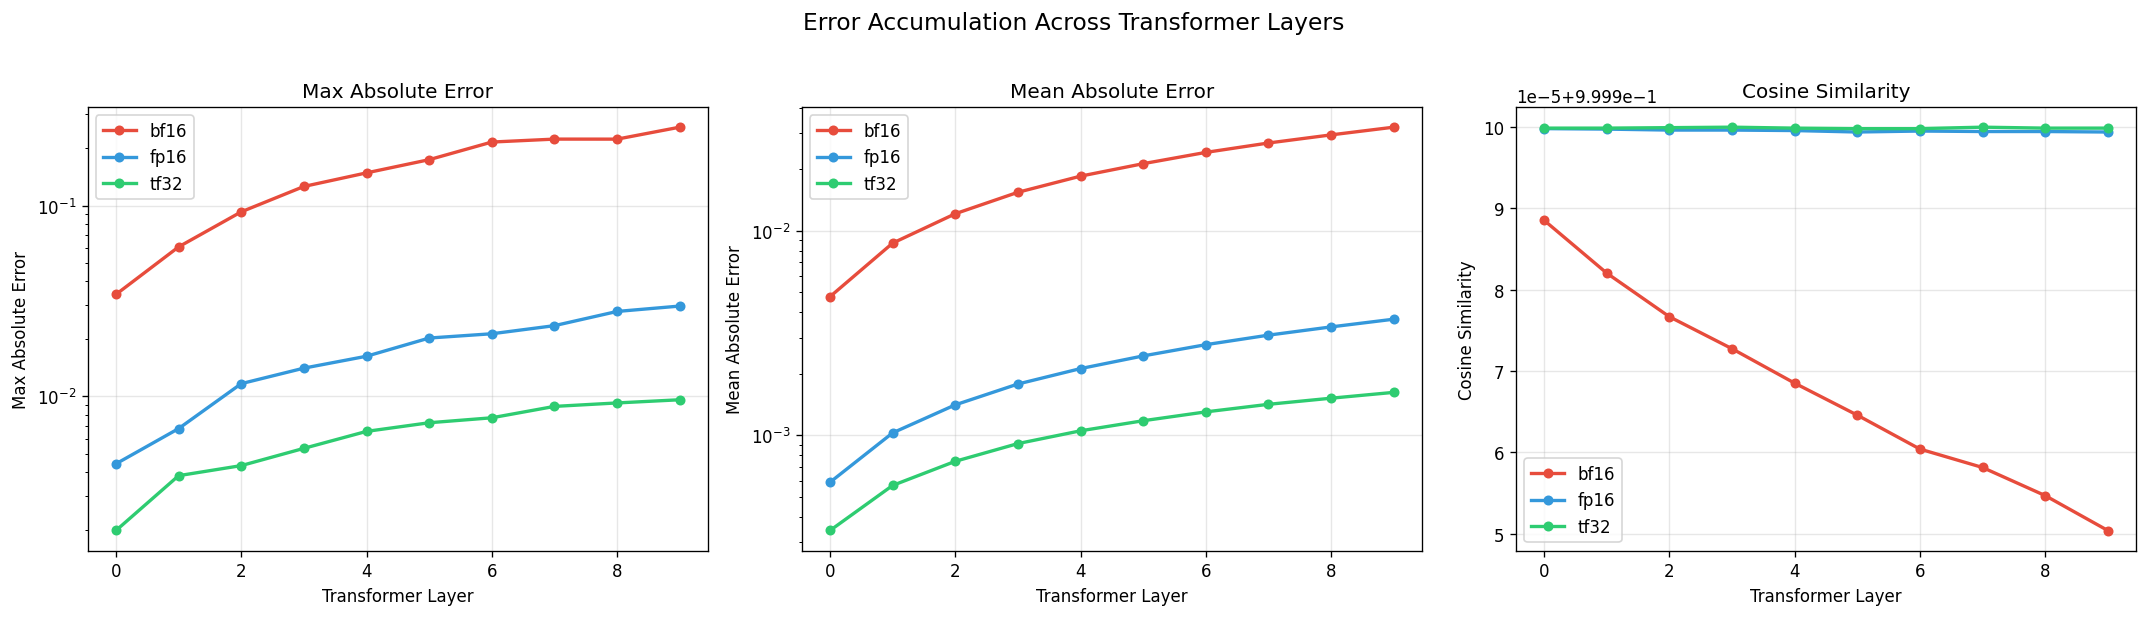

In [9]:
# Plot error accumulation across layers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_keys = ["max_abs_err", "mean_abs_err", "cosine_sim"]
metric_labels = ["Max Absolute Error", "Mean Absolute Error", "Cosine Similarity"]

for ax, mkey, mlabel in zip(axes, metric_keys, metric_labels):
    for prec_name, color in [
        ("bf16", "#e74c3c"),
        ("fp16", "#3498db"),
        ("tf32", "#2ecc71"),
    ]:
        layers = [r["layer"] for r in layer_results[prec_name]]
        vals = [r[mkey] for r in layer_results[prec_name]]
        ax.plot(
            layers, vals, "o-", label=prec_name, color=color, linewidth=2, markersize=5
        )
    ax.set_xlabel("Transformer Layer")
    ax.set_ylabel(mlabel)
    ax.set_title(mlabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    if mkey != "cosine_sim":
        ax.set_yscale("log")

fig.suptitle("Error Accumulation Across Transformer Layers", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("layer_error_accumulation.png", bbox_inches="tight", dpi=150)
plt.show()

### 3.5 PMA Pooling

In [10]:
# Full encoder output as input to pooling
torch.backends.cuda.matmul.allow_tf32 = False
model.to(torch.float32)
with torch.no_grad():
    enc_out_fp32 = model.encoder(
        mz_input.float(),
        batch["peak_intensity"].float(),
        valid_mask=batch["peak_valid_mask"],
    )
    ref_pooled = model.pool(enc_out_fp32, batch["peak_valid_mask"]).float()

print(f"PMA pooled output shape: {ref_pooled.shape}")

for prec_name, (dtype, tf32) in PRECISIONS.items():
    if prec_name == "fp32":
        continue
    # Cast pool_mha and pool_norm, feed encoder output in reduced precision
    old_tf32 = torch.backends.cuda.matmul.allow_tf32
    if tf32 == "tf32":
        torch.backends.cuda.matmul.allow_tf32 = True
    else:
        torch.backends.cuda.matmul.allow_tf32 = False

    # Create a temporary module list for pool components
    pool_q_orig = model.pool_query.data.clone()
    pool_mha_state = {k: v.clone() for k, v in model.pool_mha.state_dict().items()}
    pool_norm_state = {k: v.clone() for k, v in model.pool_norm.state_dict().items()}

    model.pool_query.data = model.pool_query.data.to(dtype)
    model.pool_mha.to(dtype)
    model.pool_norm.to(dtype)

    with torch.no_grad():
        inp = enc_out_fp32.to(dtype) if prec_name != "tf32" else enc_out_fp32
        out = model.pool(inp, batch["peak_valid_mask"]).float()

    model.pool_query.data = pool_q_orig
    model.pool_mha.load_state_dict(pool_mha_state)
    model.pool_norm.load_state_dict(pool_norm_state)
    model.pool_mha.to(torch.float32)
    model.pool_norm.to(torch.float32)
    torch.backends.cuda.matmul.allow_tf32 = old_tf32

    metrics = compute_error_metrics(ref_pooled, out)
    metrics["component"] = "PMA Pooling"
    metrics["precision"] = prec_name
    results.append(metrics)
    print(
        f"  {prec_name}: max_abs={metrics['max_abs_err']:.6f}, cos_sim={metrics['cosine_sim']:.8f}"
    )

PMA pooled output shape: torch.Size([16, 256])
  tf32: max_abs=0.001113, cos_sim=1.00000000
  bf16: max_abs=0.016050, cos_sim=0.99999446
  fp16: max_abs=0.007839, cos_sim=0.99999744


### 3.6 Projector MLP

In [11]:
projector = model.projector

torch.backends.cuda.matmul.allow_tf32 = False
with torch.no_grad():
    ref_proj = projector(ref_pooled.float()).float()

print(f"Projector output shape: {ref_proj.shape}")

for prec_name, (dtype, tf32) in PRECISIONS.items():
    if prec_name == "fp32":
        continue
    with model_precision(projector, dtype, tf32):
        with torch.no_grad():
            inp = ref_pooled.to(dtype) if prec_name != "tf32" else ref_pooled.float()
            out = projector(inp).float()
    metrics = compute_error_metrics(ref_proj, out)
    metrics["component"] = "Projector MLP"
    metrics["precision"] = prec_name
    results.append(metrics)
    print(
        f"  {prec_name}: max_abs={metrics['max_abs_err']:.6f}, cos_sim={metrics['cosine_sim']:.8f}"
    )

projector.to(torch.float32)

Projector output shape: torch.Size([16, 128])
  tf32: max_abs=0.000693, cos_sim=1.00000000
  bf16: max_abs=0.006544, cos_sim=0.99998361
  fp16: max_abs=0.003240, cos_sim=0.99999601


Sequential(
  (0): Linear(in_features=256, out_features=2048, bias=True)
  (1): RMSNorm((2048,), eps=None, elementwise_affine=True)
  (2): SiLU()
  (3): Linear(in_features=2048, out_features=2048, bias=True)
  (4): RMSNorm((2048,), eps=None, elementwise_affine=True)
  (5): SiLU()
  (6): Linear(in_features=2048, out_features=128, bias=True)
)

### 3.7 BCS Loss (Epps-Pulley)

In [12]:
bcs_loss = model.sigreg_loss

# Create two "views" from projector output
torch.manual_seed(99)
z1_fp32 = torch.randn(B, MODEL_CFG["sigreg_proj_output_dim"], device=DEVICE)
z2_fp32 = z1_fp32 + 0.1 * torch.randn_like(z1_fp32)
proj_fp32 = bcs_loss.sample_projection(
    MODEL_CFG["sigreg_proj_output_dim"], device=DEVICE, seed=42
)

torch.backends.cuda.matmul.allow_tf32 = False
with torch.no_grad():
    ref_loss_dict = bcs_loss(z1_fp32, z2_fp32, proj=proj_fp32)
    ref_loss_val = ref_loss_dict["loss"].float()
    ref_bcs_val = ref_loss_dict["bcs_loss"].float()
    ref_inv_val = ref_loss_dict["invariance_loss"].float()

print(
    f"Reference loss={ref_loss_val.item():.6f}, bcs={ref_bcs_val.item():.6f}, inv={ref_inv_val.item():.6f}"
)

bcs_results = []
for prec_name, (dtype, tf32) in PRECISIONS.items():
    if prec_name == "fp32":
        continue

    old_tf32 = torch.backends.cuda.matmul.allow_tf32
    if tf32 == "tf32":
        torch.backends.cuda.matmul.allow_tf32 = True
    else:
        torch.backends.cuda.matmul.allow_tf32 = False

    z1_t = z1_fp32.to(dtype) if prec_name != "tf32" else z1_fp32
    z2_t = z2_fp32.to(dtype) if prec_name != "tf32" else z2_fp32
    proj_t = proj_fp32.to(dtype) if prec_name != "tf32" else proj_fp32

    with torch.no_grad():
        out_dict = bcs_loss(z1_t, z2_t, proj=proj_t)

    torch.backends.cuda.matmul.allow_tf32 = old_tf32

    for loss_key, ref_val in [
        ("loss", ref_loss_val),
        ("bcs_loss", ref_bcs_val),
        ("invariance_loss", ref_inv_val),
    ]:
        test_val = out_dict[loss_key].float()
        err = (ref_val - test_val).abs().item()
        rel_err = err / max(ref_val.abs().item(), 1e-12)
        bcs_results.append(
            {
                "precision": prec_name,
                "loss_component": loss_key,
                "ref_value": ref_val.item(),
                "test_value": test_val.item(),
                "abs_error": err,
                "rel_error": rel_err,
                "has_nan": bool(test_val.isnan().any()),
            }
        )

    # Overall loss metric for main results table
    m = compute_error_metrics(
        ref_loss_val.unsqueeze(0),
        out_dict["loss"].float().unsqueeze(0),
    )
    m["component"] = "BCS Loss"
    m["precision"] = prec_name
    results.append(m)

bcs_df = pd.DataFrame(bcs_results)
print("\nBCS Loss Detailed Results:")
print(bcs_df.to_string(index=False))

Reference loss=0.016234, bcs=0.062023, inv=0.010032

BCS Loss Detailed Results:
precision  loss_component  ref_value  test_value    abs_error  rel_error  has_nan
     tf32            loss   0.016234    0.016234 8.009374e-08   0.000005    False
     tf32        bcs_loss   0.062023    0.062024 7.972121e-07   0.000013    False
     tf32 invariance_loss   0.010032    0.010032 0.000000e+00   0.000000    False
     bf16            loss   0.016234    0.016272 3.801100e-05   0.002341    False
     bf16        bcs_loss   0.062023    0.062013 1.068786e-05   0.000172    False
     bf16 invariance_loss   0.010032    0.010071 3.908016e-05   0.003896    False
     fp16            loss   0.016234    0.016235 1.028180e-06   0.000063    False
     fp16        bcs_loss   0.062023    0.062024 9.499490e-07   0.000015    False
     fp16 invariance_loss   0.010032    0.010033 9.331852e-07   0.000093    False


### 3.8 Full End-to-End: `forward_augmented`

In [13]:
# Full end-to-end comparison using forward_augmented
model.to(torch.float32)
torch.backends.cuda.matmul.allow_tf32 = False

bcs_proj = model.sample_bcs_projection(device=DEVICE, seed=42)

with torch.no_grad():
    ref_metrics = model.forward_augmented(
        cast_tensors(aug_batch, torch.float32), bcs_projection=bcs_proj
    )
    ref_loss_e2e = ref_metrics["loss"].float()

print(f"Reference E2E loss: {ref_loss_e2e.item():.6f}")

e2e_results = []
for prec_name, (dtype, tf32) in PRECISIONS.items():
    if prec_name == "fp32":
        continue

    old_tf32 = torch.backends.cuda.matmul.allow_tf32
    if tf32 == "tf32":
        torch.backends.cuda.matmul.allow_tf32 = True
    else:
        torch.backends.cuda.matmul.allow_tf32 = False

    if prec_name == "tf32":
        test_batch = cast_tensors(aug_batch, torch.float32)
        test_proj = bcs_proj.float()
    else:
        model.to(dtype)
        test_batch = cast_tensors(aug_batch, dtype)
        test_proj = bcs_proj.to(dtype)

    try:
        with torch.no_grad():
            test_metrics = model.forward_augmented(test_batch, bcs_projection=test_proj)
        status = "OK"
        test_loss = test_metrics["loss"].float().item()
        has_nan = any(
            v.isnan().any().item()
            for v in test_metrics.values()
            if isinstance(v, torch.Tensor)
        )
        has_inf = any(
            v.isinf().any().item()
            for v in test_metrics.values()
            if isinstance(v, torch.Tensor)
        )
    except Exception as e:
        status = f"ERROR: {e}"
        test_loss = float("nan")
        has_nan = True
        has_inf = False

    torch.backends.cuda.matmul.allow_tf32 = old_tf32
    model.to(torch.float32)

    abs_err = abs(ref_loss_e2e.item() - test_loss)
    rel_err = abs_err / max(abs(ref_loss_e2e.item()), 1e-12)
    e2e_results.append(
        {
            "precision": prec_name,
            "ref_loss": ref_loss_e2e.item(),
            "test_loss": test_loss,
            "abs_error": abs_err,
            "rel_error": rel_err,
            "has_nan": has_nan,
            "has_inf": has_inf,
            "status": status,
        }
    )

    # For main results table
    m = {
        "component": "E2E forward_augmented",
        "precision": prec_name,
        "max_abs_err": abs_err,
        "mean_abs_err": abs_err,
        "max_rel_err": rel_err,
        "mean_rel_err": rel_err,
        "cosine_sim": 1.0 if not has_nan else 0.0,
        "has_nan": has_nan,
        "has_inf": has_inf,
        "output_range": f"{test_loss:.4g}",
    }
    results.append(m)

    # Per-metric comparison
    if status == "OK":
        for mk in [
            "loss",
            "bcs_loss",
            "invariance_loss",
            "alignment",
            "uniformity",
            "representation_variance",
            "encoder_variance",
        ]:
            rv = ref_metrics[mk].float().item()
            tv = test_metrics[mk].float().item()
            e2e_results.append(
                {
                    "precision": prec_name,
                    "ref_loss": rv,
                    "test_loss": tv,
                    "abs_error": abs(rv - tv),
                    "rel_error": abs(rv - tv) / max(abs(rv), 1e-12),
                    "has_nan": bool(test_metrics[mk].isnan().any()),
                    "has_inf": bool(test_metrics[mk].isinf().any()),
                    "status": mk,
                }
            )

e2e_df = pd.DataFrame(e2e_results)
print("\nE2E Forward Results:")
print(e2e_df.to_string(index=False))

Reference E2E loss: 0.081245



E2E Forward Results:
precision  ref_loss  test_loss  abs_error  rel_error  has_nan  has_inf                  status
     tf32  0.081245   0.081248   0.000002   0.000028    False    False                      OK
     tf32  0.081245   0.081248   0.000002   0.000028    False    False                    loss
     tf32  0.458824   0.458821   0.000003   0.000007    False    False                bcs_loss
     tf32  0.035363   0.035366   0.000003   0.000074    False    False         invariance_loss
     tf32  0.861775   0.861765   0.000010   0.000012    False    False               alignment
     tf32  0.865279   0.865267   0.000012   0.000013    False    False              uniformity
     tf32  0.016779   0.016780   0.000002   0.000102    False    False representation_variance
     tf32  0.142223   0.142229   0.000006   0.000045    False    False        encoder_variance
     bf16  0.081245   0.079114   0.002132   0.026239    False    False                      OK
     bf16  0.081245   0.0791

## 4. Summary Heatmap: All Components x Precisions

In [14]:
df = pd.DataFrame(results)
print("\n=== Full Results Table ===")
print(
    df[
        [
            "component",
            "precision",
            "max_abs_err",
            "mean_abs_err",
            "max_rel_err",
            "cosine_sim",
            "has_nan",
            "has_inf",
        ]
    ].to_string(index=False)
)


=== Full Results Table ===
              component precision  max_abs_err  mean_abs_err  max_rel_err  cosine_sim  has_nan  has_inf
        FourierFeatures      tf32 0.000000e+00  0.000000e+00 0.000000e+00    1.000000    False    False
        FourierFeatures      bf16 2.000000e+00  3.528256e-01 9.909278e+04    0.621641    False    False
        FourierFeatures      fp16 1.999997e+00  3.390891e-01 9.903023e+04    0.632803    False    False
    PeakFeatureEmbedder      tf32 6.777346e-04  1.041639e-04 5.739078e+04    1.000000    False    False
    PeakFeatureEmbedder      bf16 1.657403e+00  2.088307e-01 1.184139e+08    0.644791    False    False
    PeakFeatureEmbedder      fp16 1.194420e+00  1.161895e-01 2.980062e+07    0.865703    False    False
    TransformerBlock[0]      tf32 2.986431e-03  4.785967e-04 2.479821e+02    1.000000    False    False
    TransformerBlock[0]      bf16 3.401542e-02  5.516625e-03 2.924714e+03    0.999985    False    False
    TransformerBlock[0]      fp16 1.

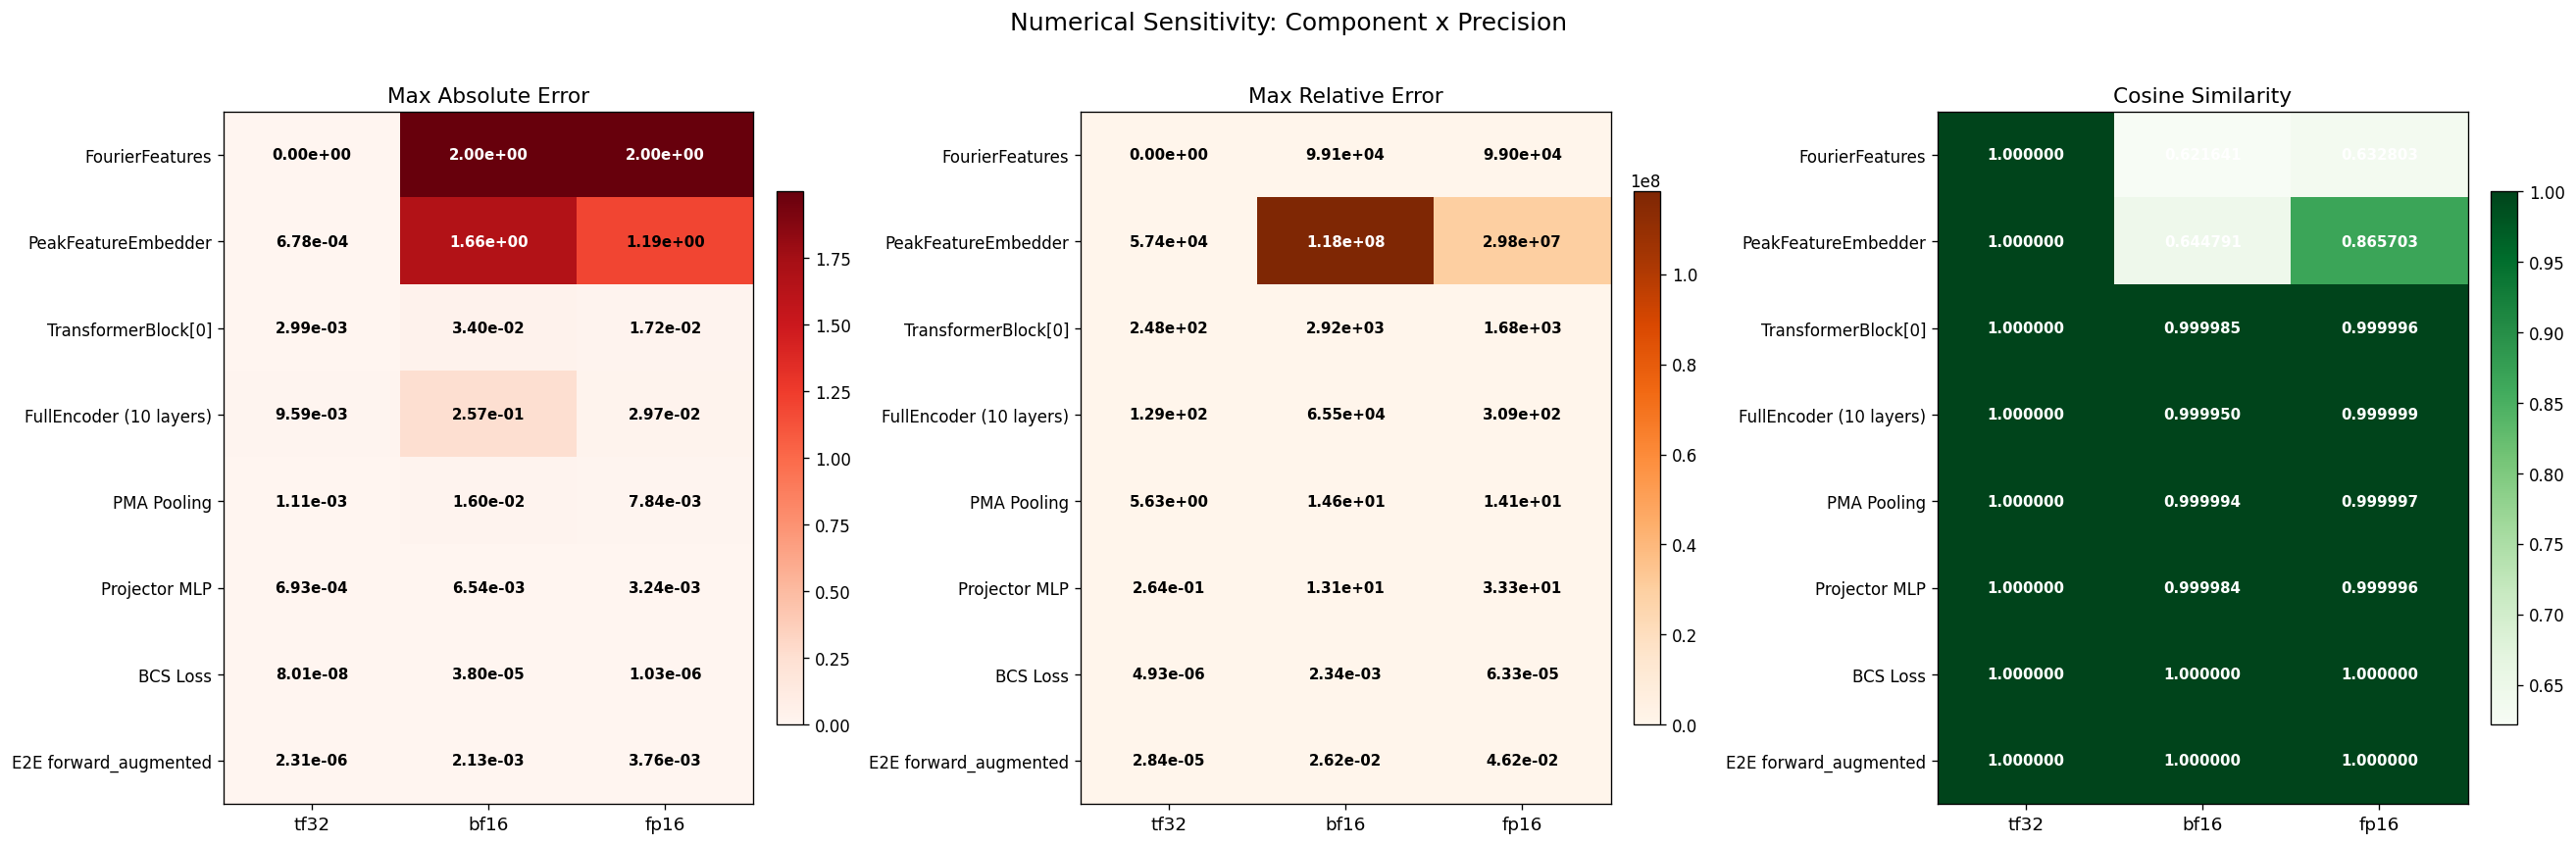

In [15]:
# Heatmap: max_abs_err for each component x precision
pivot_abs = df.pivot_table(index="component", columns="precision", values="max_abs_err")
pivot_rel = df.pivot_table(index="component", columns="precision", values="max_rel_err")
pivot_cos = df.pivot_table(index="component", columns="precision", values="cosine_sim")

# Order components by pipeline order
component_order = [
    "FourierFeatures",
    "PeakFeatureEmbedder",
    "TransformerBlock[0]",
    "FullEncoder (10 layers)",
    "PMA Pooling",
    "Projector MLP",
    "BCS Loss",
    "E2E forward_augmented",
]
prec_order = ["tf32", "bf16", "fp16"]

for pivot in [pivot_abs, pivot_rel, pivot_cos]:
    pivot_idx = [c for c in component_order if c in pivot.index]
    pivot_col = [c for c in prec_order if c in pivot.columns]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, pivot, title, cmap, fmt in [
    (axes[0], pivot_abs, "Max Absolute Error", "Reds", ".2e"),
    (axes[1], pivot_rel, "Max Relative Error", "Oranges", ".2e"),
    (axes[2], pivot_cos, "Cosine Similarity", "Greens", ".6f"),
]:
    data = pivot.reindex(
        index=[c for c in component_order if c in pivot.index],
        columns=[c for c in prec_order if c in pivot.columns],
    )

    im = ax.imshow(data.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, fontsize=11)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=10)
    ax.set_title(title, fontsize=13)

    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            val = data.values[i, j]
            if not np.isnan(val):
                ax.text(
                    j,
                    i,
                    f"{val:{fmt}}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color="white" if val > data.values.max() * 0.6 else "black",
                )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Numerical Sensitivity: Component x Precision", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("precision_sensitivity_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

## 5. Distribution of Errors per Component

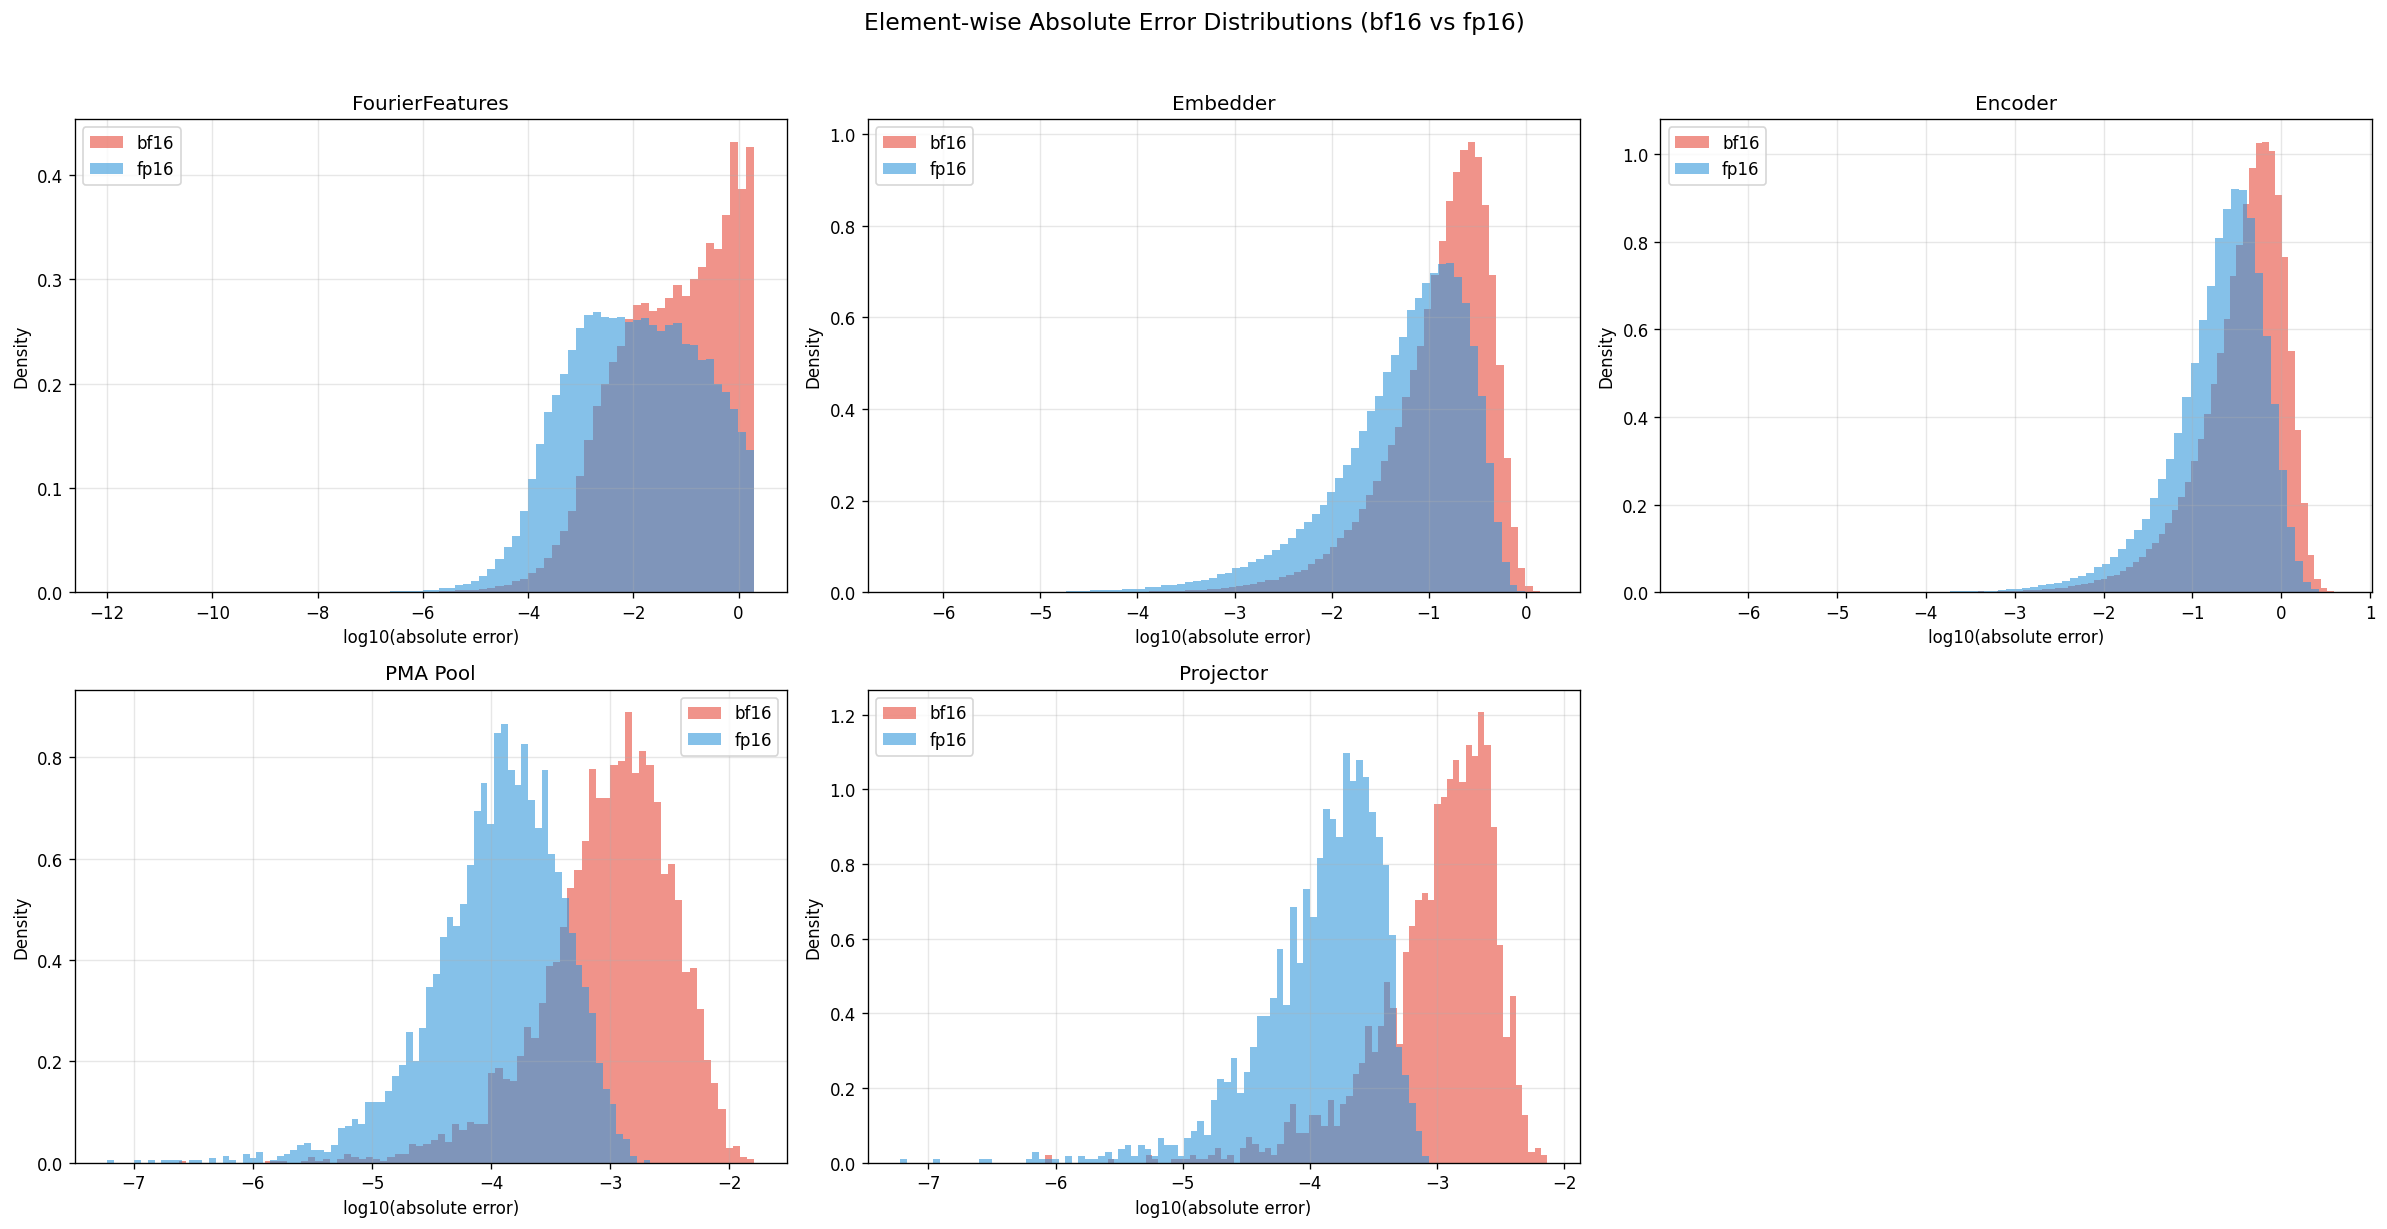

In [16]:
# Detailed element-wise error distributions for key components
model.to(torch.float32)
torch.backends.cuda.matmul.allow_tf32 = False

components_to_profile = {}

with torch.no_grad():
    # FourierFeatures
    components_to_profile["FourierFeatures"] = fourier(mz_input.float()).float()
    # Embedder
    emb_out = embedder(mz_input.float(), batch["peak_intensity"].float())
    components_to_profile["Embedder"] = emb_out.float()
    # Full encoder
    enc_out = model.encoder(
        mz_input.float(),
        batch["peak_intensity"].float(),
        valid_mask=batch["peak_valid_mask"],
    )
    components_to_profile["Encoder"] = enc_out.float()
    # Pooling
    pool_out = model.pool(enc_out, batch["peak_valid_mask"])
    components_to_profile["PMA Pool"] = pool_out.float()
    # Projector
    proj_out = model.projector(pool_out)
    components_to_profile["Projector"] = proj_out.float()

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for idx, (comp_name, ref_output) in enumerate(components_to_profile.items()):
    ax = axes[idx]
    for prec_name, color in [("bf16", "#e74c3c"), ("fp16", "#3498db")]:
        dtype = PRECISIONS[prec_name][0]
        # Run in reduced precision
        if comp_name == "FourierFeatures":
            with model_precision(fourier, dtype):
                with torch.no_grad():
                    test_out = fourier(mz_input.to(dtype)).float()
            fourier.to(torch.float32)
        elif comp_name == "Embedder":
            with model_precision(embedder, dtype):
                with torch.no_grad():
                    test_out = embedder(
                        mz_input.to(dtype), batch["peak_intensity"].to(dtype)
                    ).float()
            embedder.to(torch.float32)
        elif comp_name == "Encoder":
            with model_precision(model.encoder, dtype):
                with torch.no_grad():
                    test_out = model.encoder(
                        mz_input.to(dtype),
                        batch["peak_intensity"].to(dtype),
                        valid_mask=batch["peak_valid_mask"],
                    ).float()
            model.encoder.to(torch.float32)
        elif comp_name == "PMA Pool":
            pool_q_orig = model.pool_query.data.clone()
            model.pool_query.data = model.pool_query.data.to(dtype)
            model.pool_mha.to(dtype)
            model.pool_norm.to(dtype)
            with torch.no_grad():
                test_out = model.pool(
                    enc_out.to(dtype), batch["peak_valid_mask"]
                ).float()
            model.pool_query.data = pool_q_orig
            model.pool_mha.to(torch.float32)
            model.pool_norm.to(torch.float32)
        elif comp_name == "Projector":
            with model_precision(model.projector, dtype):
                with torch.no_grad():
                    test_out = model.projector(pool_out.to(dtype)).float()
            model.projector.to(torch.float32)

        errors = (ref_output - test_out).abs().flatten().cpu().numpy()
        errors_log = np.log10(errors + 1e-12)
        ax.hist(
            errors_log, bins=80, alpha=0.6, label=prec_name, color=color, density=True
        )

    ax.set_title(comp_name, fontsize=12)
    ax.set_xlabel("log10(absolute error)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove unused subplot
if len(components_to_profile) < len(axes):
    for i in range(len(components_to_profile), len(axes)):
        axes[i].set_visible(False)

fig.suptitle(
    "Element-wise Absolute Error Distributions (bf16 vs fp16)", fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig("error_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

## 6. FourierFeatures: Frequency-Dependent Error Analysis

The FourierFeatures layer computes `sin(mz * freq * 2pi)` and `cos(mz * freq * 2pi)` with
frequencies up to 5000 Hz. This creates products up to ~31,400 which overflow fp16 (max 65,504)
and lose precision in bf16 (7-bit mantissa → quantization step ~2048 at high magnitudes).

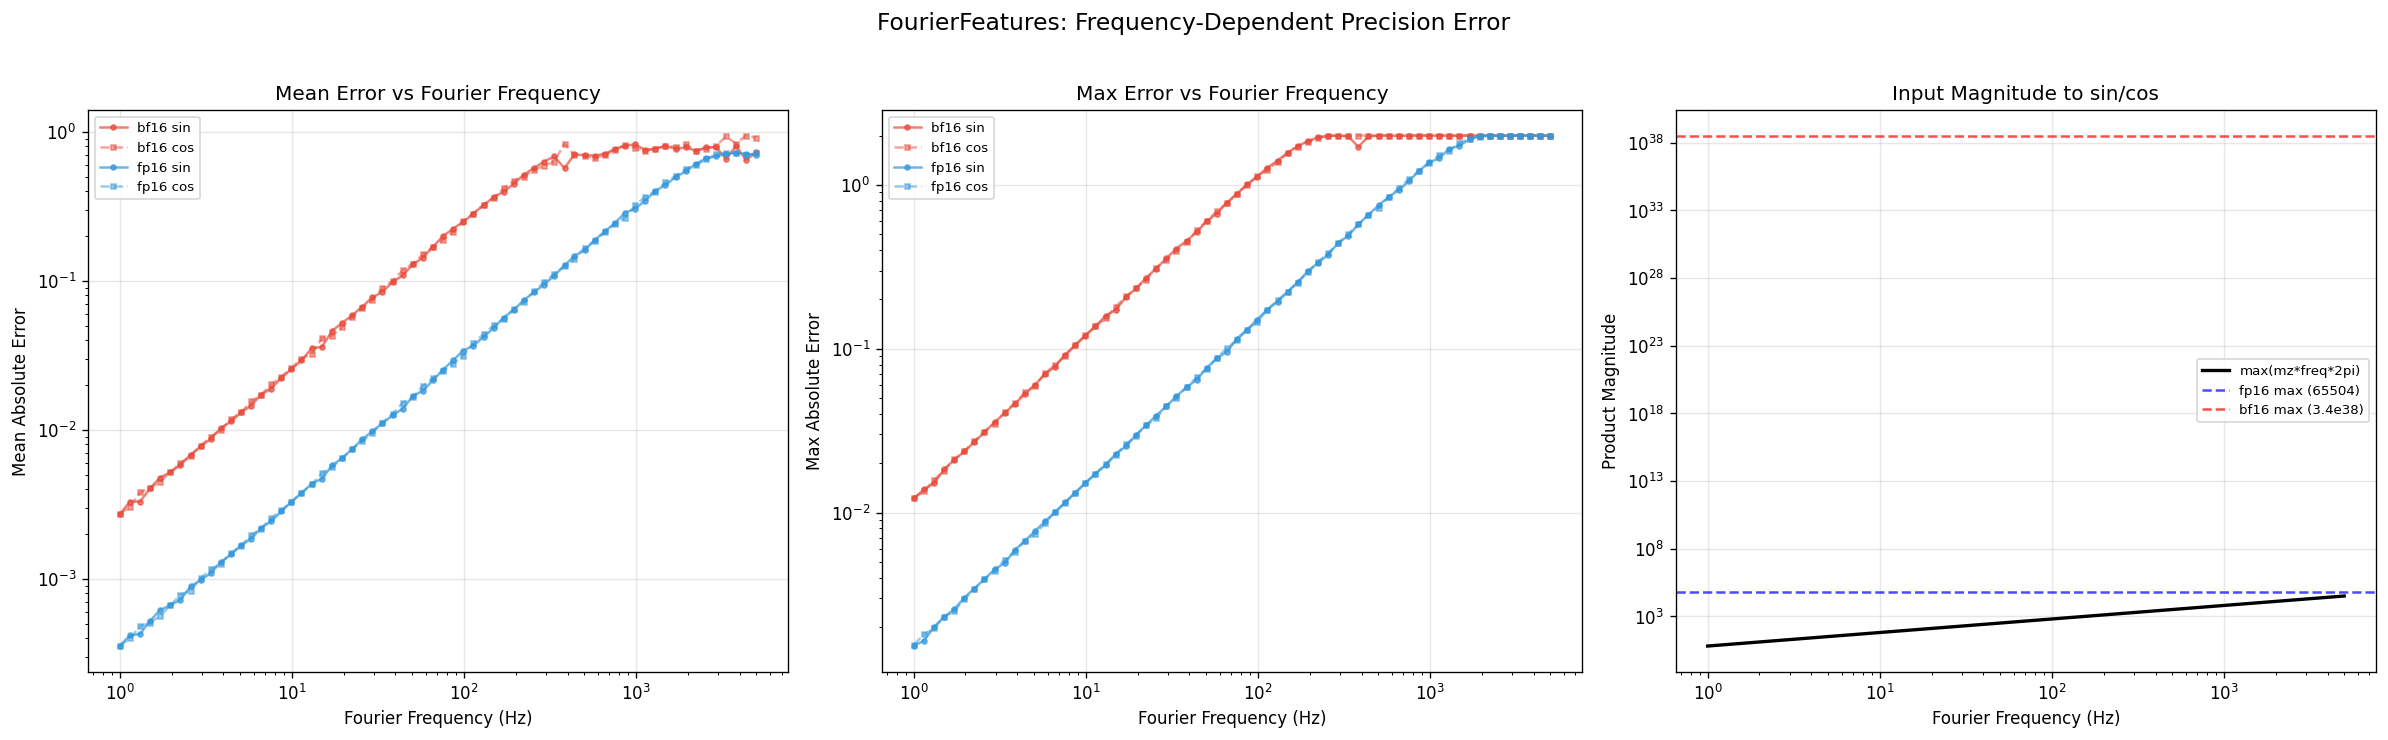

In [17]:
# Analyze error as a function of frequency index
fourier.to(torch.float32)

freqs = fourier.freqs.cpu().numpy()
num_freq = len(freqs)

torch.backends.cuda.matmul.allow_tf32 = False
with torch.no_grad():
    ref_ff = fourier(mz_input.float()).float()  # [B, N, 2*num_freq]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for prec_name, color in [("bf16", "#e74c3c"), ("fp16", "#3498db")]:
    dtype = PRECISIONS[prec_name][0]
    with model_precision(fourier, dtype):
        with torch.no_grad():
            test_ff = fourier(mz_input.to(dtype)).float()
    fourier.to(torch.float32)

    # Error per frequency (sin and cos channels)
    errs = (ref_ff - test_ff).abs()  # [B, N, 2*num_freq]
    # sin channels: 0..num_freq-1, cos channels: num_freq..2*num_freq-1
    sin_errs = errs[:, :, :num_freq].mean(dim=(0, 1)).cpu().numpy()
    cos_errs = errs[:, :, num_freq:].mean(dim=(0, 1)).cpu().numpy()

    axes[0].semilogy(
        freqs,
        sin_errs,
        "o-",
        label=f"{prec_name} sin",
        color=color,
        alpha=0.7,
        markersize=3,
    )
    axes[0].semilogy(
        freqs,
        cos_errs,
        "s--",
        label=f"{prec_name} cos",
        color=color,
        alpha=0.5,
        markersize=3,
    )

    # Max error per frequency
    sin_max_errs = errs[:, :, :num_freq].amax(dim=(0, 1)).cpu().numpy()
    cos_max_errs = errs[:, :, num_freq:].amax(dim=(0, 1)).cpu().numpy()
    axes[1].semilogy(
        freqs,
        sin_max_errs,
        "o-",
        label=f"{prec_name} sin",
        color=color,
        alpha=0.7,
        markersize=3,
    )
    axes[1].semilogy(
        freqs,
        cos_max_errs,
        "s--",
        label=f"{prec_name} cos",
        color=color,
        alpha=0.5,
        markersize=3,
    )

axes[0].set_xlabel("Fourier Frequency (Hz)")
axes[0].set_ylabel("Mean Absolute Error")
axes[0].set_title("Mean Error vs Fourier Frequency")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale("log")

axes[1].set_xlabel("Fourier Frequency (Hz)")
axes[1].set_ylabel("Max Absolute Error")
axes[1].set_title("Max Error vs Fourier Frequency")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale("log")

# Show the magnitude of mz * freq * 2pi
mz_vals = mz_input.float().flatten().cpu().numpy()
products = np.outer(mz_vals, freqs) * 2 * math.pi
axes[2].semilogy(
    freqs, products.max(axis=0), "k-", label="max(mz*freq*2pi)", linewidth=2
)
axes[2].axhline(
    65504, color="blue", linestyle="--", label="fp16 max (65504)", alpha=0.7
)
axes[2].axhline(
    3.4e38, color="red", linestyle="--", label="bf16 max (3.4e38)", alpha=0.7
)
axes[2].set_xlabel("Fourier Frequency (Hz)")
axes[2].set_ylabel("Product Magnitude")
axes[2].set_title("Input Magnitude to sin/cos")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
axes[2].set_xscale("log")

fig.suptitle(
    "FourierFeatures: Frequency-Dependent Precision Error", fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig("fourier_frequency_errors.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Attention Score Sensitivity

Examine how precision affects attention patterns in the transformer.

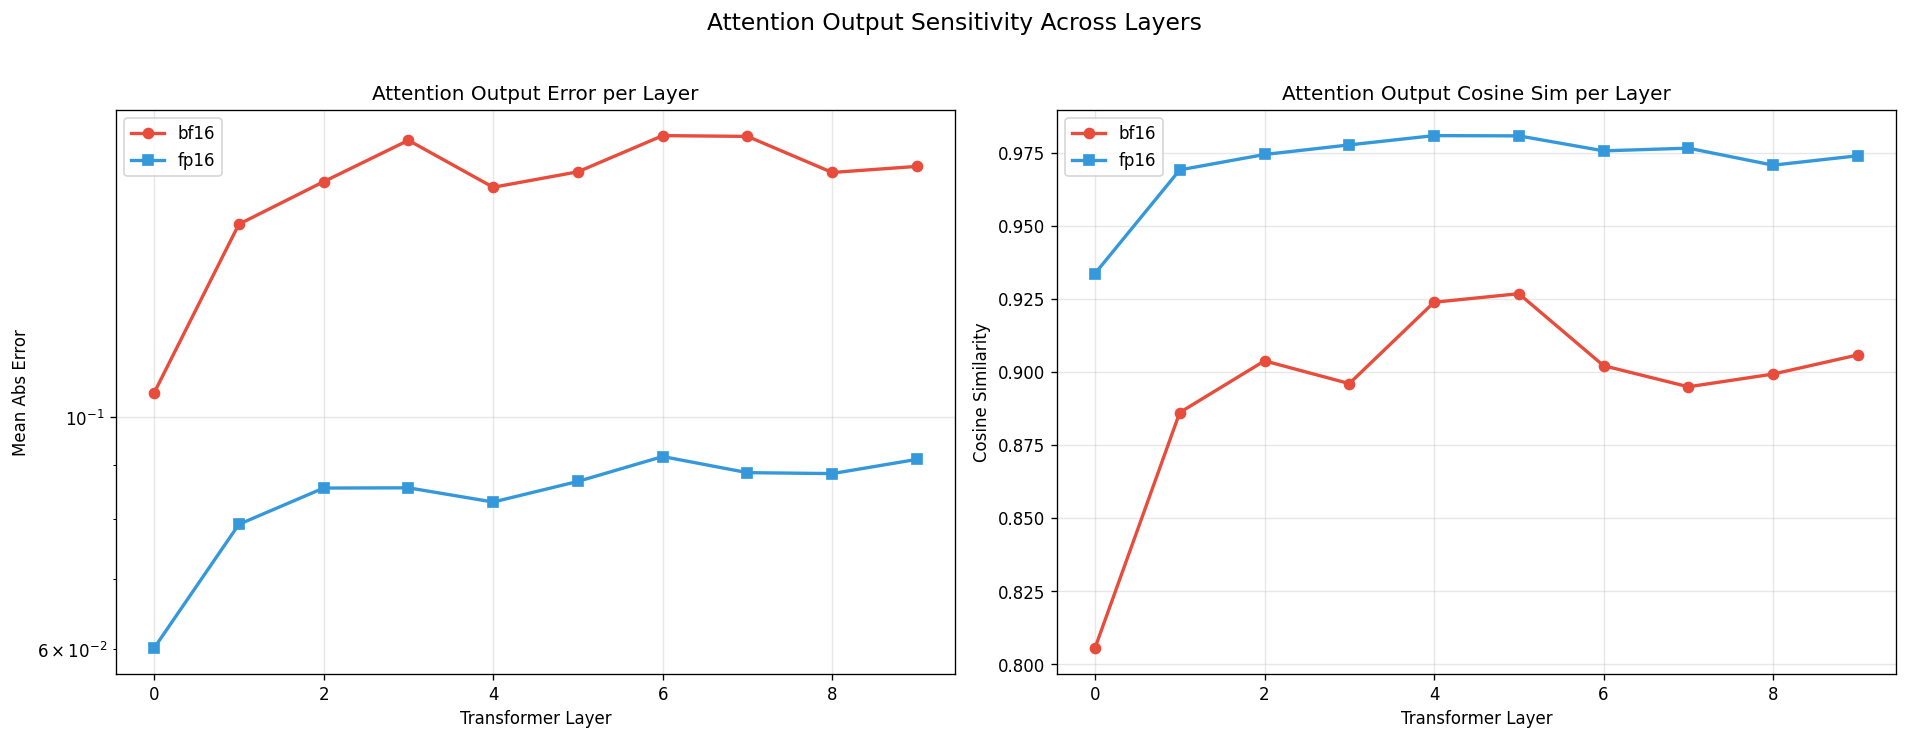

In [18]:
# Compare attention score distributions across precisions
# We hook into the attention layer of the first block
from networks.transformer_torch import Attention

attn_outputs = {}


def make_hook(name):
    def hook_fn(module, input, output):
        attn_outputs[name] = output.detach().float()

    return hook_fn


model.to(torch.float32)
torch.backends.cuda.matmul.allow_tf32 = False

# Register hooks on each block's attention output
hooks = []
for i, block in enumerate(model.encoder.blocks):
    h = block.attention.register_forward_hook(make_hook(f"block_{i}"))
    hooks.append(h)

# Run fp32 reference
with torch.no_grad():
    _ = model.encoder(
        mz_input.float(),
        batch["peak_intensity"].float(),
        valid_mask=batch["peak_valid_mask"],
    )
ref_attn = {k: v.clone() for k, v in attn_outputs.items()}

# Run bf16
attn_outputs.clear()
with model_precision(model.encoder, torch.bfloat16):
    with torch.no_grad():
        _ = model.encoder(
            mz_input.bfloat16(),
            batch["peak_intensity"].bfloat16(),
            valid_mask=batch["peak_valid_mask"],
        )
bf16_attn = {k: v.clone() for k, v in attn_outputs.items()}
model.encoder.to(torch.float32)

# Run fp16
attn_outputs.clear()
with model_precision(model.encoder, torch.float16):
    with torch.no_grad():
        try:
            _ = model.encoder(
                mz_input.half(),
                batch["peak_intensity"].half(),
                valid_mask=batch["peak_valid_mask"],
            )
            fp16_attn = {k: v.clone() for k, v in attn_outputs.items()}
        except RuntimeError as e:
            print(f"fp16 attention failed: {e}")
            fp16_attn = None
model.encoder.to(torch.float32)

# Remove hooks
for h in hooks:
    h.remove()

# Plot attention output divergence per layer
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

layers = list(range(len(model.encoder.blocks)))
bf16_errs = [
    compute_error_metrics(ref_attn[f"block_{i}"], bf16_attn[f"block_{i}"])[
        "mean_abs_err"
    ]
    for i in layers
]
bf16_cos = [
    compute_error_metrics(ref_attn[f"block_{i}"], bf16_attn[f"block_{i}"])["cosine_sim"]
    for i in layers
]

axes[0].semilogy(layers, bf16_errs, "o-", label="bf16", color="#e74c3c", linewidth=2)
if fp16_attn is not None:
    fp16_errs = [
        compute_error_metrics(ref_attn[f"block_{i}"], fp16_attn[f"block_{i}"])[
            "mean_abs_err"
        ]
        for i in layers
    ]
    axes[0].semilogy(
        layers, fp16_errs, "s-", label="fp16", color="#3498db", linewidth=2
    )
axes[0].set_xlabel("Transformer Layer")
axes[0].set_ylabel("Mean Abs Error")
axes[0].set_title("Attention Output Error per Layer")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(layers, bf16_cos, "o-", label="bf16", color="#e74c3c", linewidth=2)
if fp16_attn is not None:
    fp16_cos = [
        compute_error_metrics(ref_attn[f"block_{i}"], fp16_attn[f"block_{i}"])[
            "cosine_sim"
        ]
        for i in layers
    ]
    axes[1].plot(layers, fp16_cos, "s-", label="fp16", color="#3498db", linewidth=2)
axes[1].set_xlabel("Transformer Layer")
axes[1].set_ylabel("Cosine Similarity")
axes[1].set_title("Attention Output Cosine Sim per Layer")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("Attention Output Sensitivity Across Layers", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("attention_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()

## 8. torch.compile Mode Sensitivity

Compare numerical outputs under different `torch.compile` modes:
- `default`
- `reduce-overhead`
- `max-autotune`

Each compile mode may use different kernel implementations (e.g., cuDNN vs custom Triton)
which can produce slightly different floating-point results.

In [19]:
# torch.compile sensitivity analysis
model.to(torch.float32)
model.eval()
torch.backends.cuda.matmul.allow_tf32 = False

compile_modes = ["default", "reduce-overhead", "max-autotune"]
autocast_dtypes = {
    "no_autocast": None,
    "bf16_autocast": torch.bfloat16,
    "fp16_autocast": torch.float16,
}

# Reference: eager mode, fp32, no autocast
aug_batch_fp32 = cast_tensors(aug_batch, torch.float32)
bcs_proj_fp32 = model.sample_bcs_projection(device=DEVICE, seed=42)

with torch.no_grad():
    ref_eager = model.forward_augmented(aug_batch_fp32, bcs_projection=bcs_proj_fp32)
    ref_loss_eager = ref_eager["loss"].float().item()

compile_results = []

for mode in compile_modes:
    for ac_name, ac_dtype in autocast_dtypes.items():
        torch._dynamo.reset()  # Clear compile cache
        model.to(torch.float32)

        compiled_fn = torch.compile(model.forward_augmented, mode=mode)

        try:
            with torch.no_grad():
                if ac_dtype is not None:
                    with torch.autocast("cuda", dtype=ac_dtype):
                        torch.compiler.cudagraph_mark_step_begin()
                        out = compiled_fn(aug_batch_fp32, bcs_projection=bcs_proj_fp32)
                else:
                    torch.compiler.cudagraph_mark_step_begin()
                    out = compiled_fn(aug_batch_fp32, bcs_projection=bcs_proj_fp32)

            test_loss = out["loss"].float().item()
            has_nan = any(
                v.isnan().any().item()
                for v in out.values()
                if isinstance(v, torch.Tensor)
            )
            has_inf = any(
                v.isinf().any().item()
                for v in out.values()
                if isinstance(v, torch.Tensor)
            )
            abs_err = abs(ref_loss_eager - test_loss)
            rel_err = abs_err / max(abs(ref_loss_eager), 1e-12)
            status = "OK"

            # Per-metric comparison
            metric_errs = {}
            for mk in [
                "loss",
                "bcs_loss",
                "invariance_loss",
                "alignment",
                "uniformity",
            ]:
                rv = ref_eager[mk].float().item()
                tv = out[mk].float().item()
                metric_errs[mk] = {
                    "ref": rv,
                    "test": tv,
                    "abs_err": abs(rv - tv),
                    "rel_err": abs(rv - tv) / max(abs(rv), 1e-12),
                }

        except Exception as e:
            test_loss = float("nan")
            has_nan = True
            has_inf = False
            abs_err = float("nan")
            rel_err = float("nan")
            status = str(e)[:80]
            metric_errs = {}

        compile_results.append(
            {
                "compile_mode": mode,
                "autocast": ac_name,
                "ref_loss": ref_loss_eager,
                "test_loss": test_loss,
                "abs_error": abs_err,
                "rel_error": rel_err,
                "has_nan": has_nan,
                "has_inf": has_inf,
                "status": status,
                "metric_details": metric_errs,
            }
        )

        print(
            f"  {mode:20s} + {ac_name:15s}: loss={test_loss:.6f}, "
            f"abs_err={abs_err:.2e}, nan={has_nan}, status={status}"
        )

torch._dynamo.reset()
compile_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k != "metric_details"} for r in compile_results]
)
print("\n=== torch.compile Results ===")
print(compile_df.to_string(index=False))

  default              + no_autocast    : loss=0.081193, abs_err=1.49e-08, nan=False, status=OK


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/torch/_dynamo/utils.py:3694: UserWarning: Mismatch dtype between input and weight: input dtype = c10::BFloat16, weight dtype = float, Cannot dispatch to fused implementation. (Triggered internally at /pytorch/aten/src/ATen/native/layer_norm.cpp:344.)
  return node.target(*args, **kwargs)  # type: ignore[operator]


  default              + bf16_autocast  : loss=0.081173, abs_err=2.02e-05, nan=False, status=OK


  default              + fp16_autocast  : loss=0.081189, abs_err=4.15e-06, nan=False, status=OK


  reduce-overhead      + no_autocast    : loss=0.081193, abs_err=1.49e-08, nan=False, status=OK


  reduce-overhead      + bf16_autocast  : loss=0.081173, abs_err=2.02e-05, nan=False, status=OK


  reduce-overhead      + fp16_autocast  : loss=0.081189, abs_err=4.15e-06, nan=False, status=OK


  max-autotune         + no_autocast    : loss=0.081193, abs_err=7.45e-09, nan=False, status=OK


  max-autotune         + bf16_autocast  : loss=0.081198, abs_err=4.82e-06, nan=False, status=OK


  max-autotune         + fp16_autocast  : loss=0.081188, abs_err=5.48e-06, nan=False, status=OK

=== torch.compile Results ===
   compile_mode      autocast  ref_loss  test_loss    abs_error    rel_error  has_nan  has_inf status
        default   no_autocast  0.081193   0.081193 1.490116e-08 1.835274e-07    False    False     OK
        default bf16_autocast  0.081193   0.081173 2.016127e-05 2.483126e-04    False    False     OK
        default fp16_autocast  0.081193   0.081189 4.149973e-06 5.111238e-05    False    False     OK
reduce-overhead   no_autocast  0.081193   0.081193 1.490116e-08 1.835274e-07    False    False     OK
reduce-overhead bf16_autocast  0.081193   0.081173 2.016127e-05 2.483126e-04    False    False     OK
reduce-overhead fp16_autocast  0.081193   0.081189 4.149973e-06 5.111238e-05    False    False     OK
   max-autotune   no_autocast  0.081193   0.081193 7.450581e-09 9.176369e-08    False    False     OK
   max-autotune bf16_autocast  0.081193   0.081198 4.8205

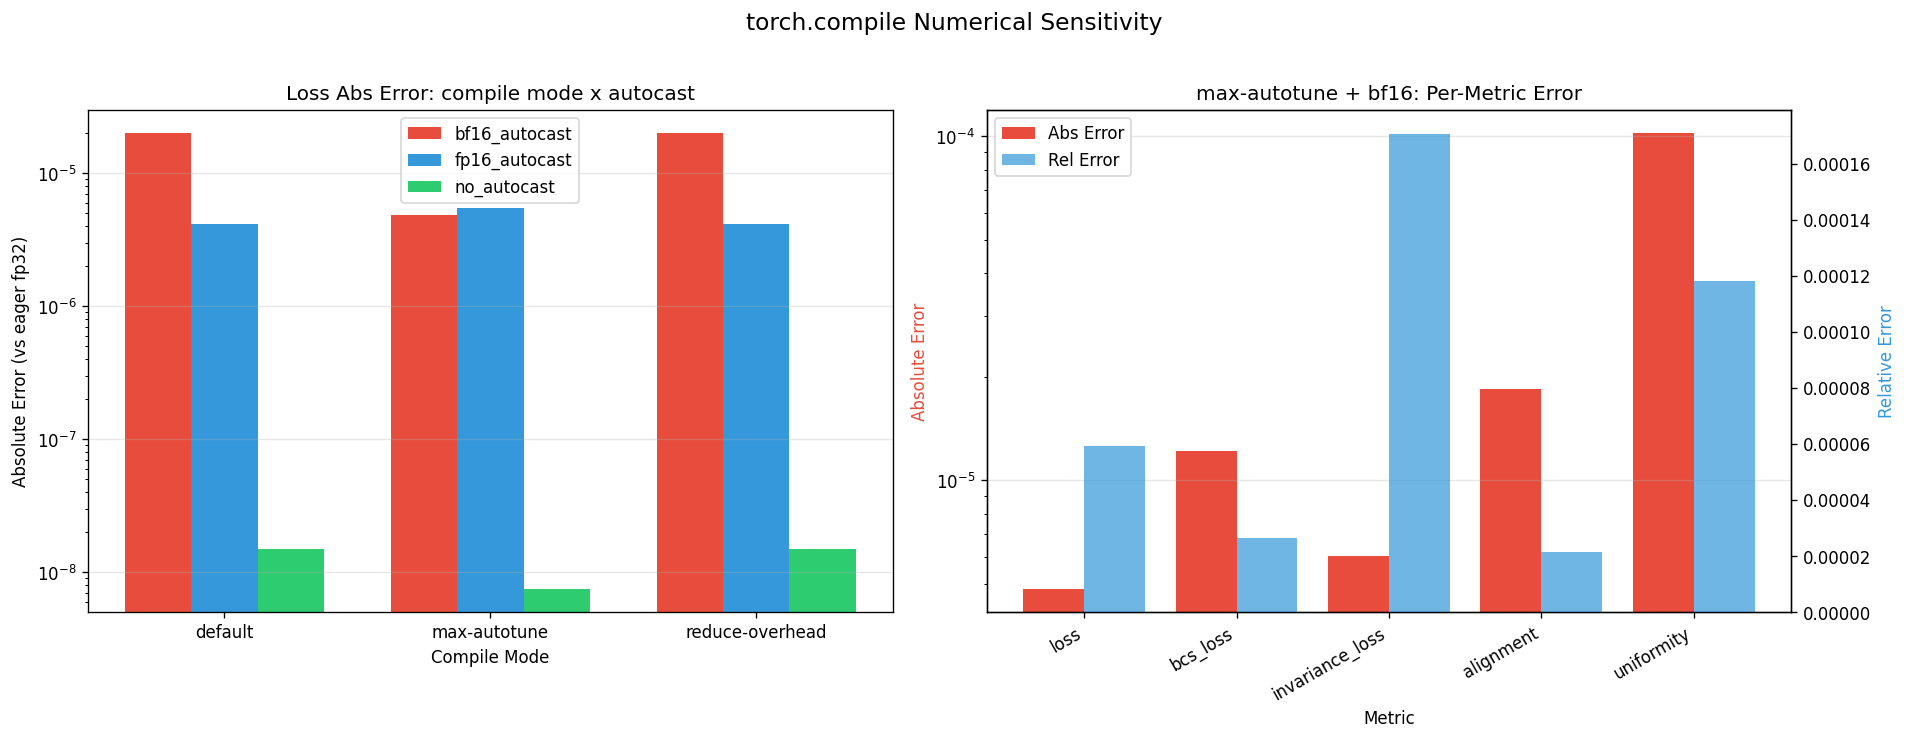

In [20]:
# Visualize compile mode results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: abs error per compile_mode x autocast
ok_results = [r for r in compile_results if r["status"] == "OK"]

modes_present = sorted(set(r["compile_mode"] for r in ok_results))
ac_present = sorted(set(r["autocast"] for r in ok_results))
colors = {
    "no_autocast": "#2ecc71",
    "bf16_autocast": "#e74c3c",
    "fp16_autocast": "#3498db",
}

x = np.arange(len(modes_present))
width = 0.25

for i, ac in enumerate(ac_present):
    vals = []
    for mode in modes_present:
        matching = [
            r for r in ok_results if r["compile_mode"] == mode and r["autocast"] == ac
        ]
        vals.append(matching[0]["abs_error"] if matching else 0)
    axes[0].bar(x + i * width, vals, width, label=ac, color=colors.get(ac, "gray"))

axes[0].set_xlabel("Compile Mode")
axes[0].set_ylabel("Absolute Error (vs eager fp32)")
axes[0].set_title("Loss Abs Error: compile mode x autocast")
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(modes_present)
axes[0].legend()
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3, axis="y")

# Per-metric breakdown for max-autotune + bf16_autocast
target = [
    r
    for r in compile_results
    if r["compile_mode"] == "max-autotune"
    and r["autocast"] == "bf16_autocast"
    and r["status"] == "OK"
]
if target and target[0]["metric_details"]:
    md = target[0]["metric_details"]
    metric_names = list(md.keys())
    abs_errs = [md[k]["abs_err"] for k in metric_names]
    rel_errs = [md[k]["rel_err"] for k in metric_names]

    x2 = np.arange(len(metric_names))
    axes[1].bar(x2 - 0.2, abs_errs, 0.4, label="Abs Error", color="#e74c3c")
    ax2 = axes[1].twinx()
    ax2.bar(x2 + 0.2, rel_errs, 0.4, label="Rel Error", color="#3498db", alpha=0.7)

    axes[1].set_xlabel("Metric")
    axes[1].set_ylabel("Absolute Error", color="#e74c3c")
    ax2.set_ylabel("Relative Error", color="#3498db")
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(metric_names, rotation=30, ha="right")
    axes[1].set_title("max-autotune + bf16: Per-Metric Error")
    axes[1].set_yscale("log")
    axes[1].grid(True, alpha=0.3, axis="y")

    lines1, labels1 = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[1].legend(lines1 + lines2, labels1 + labels2)
else:
    axes[1].text(
        0.5,
        0.5,
        "max-autotune + bf16 failed or no data",
        transform=axes[1].transAxes,
        ha="center",
    )

fig.suptitle("torch.compile Numerical Sensitivity", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("compile_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()

## 9. Gradient Sensitivity Under Mixed Precision

Gradients are especially sensitive to numerical precision as errors compound during backpropagation.

In [21]:
# Gradient comparison: fp32 vs autocast bf16/fp16
torch._dynamo.reset()
model.to(torch.float32)
model.train()

aug_batch_grad = make_augmented_batch(batch_size=8)  # smaller for grad computation
aug_batch_grad_fp32 = cast_tensors(aug_batch_grad, torch.float32)
bcs_proj_grad = model.sample_bcs_projection(device=DEVICE, seed=42)


def compute_gradients(use_autocast=False, ac_dtype=torch.bfloat16):
    model.zero_grad()
    if use_autocast:
        with torch.autocast("cuda", dtype=ac_dtype):
            out = model.forward_augmented(
                aug_batch_grad_fp32, bcs_projection=bcs_proj_grad
            )
    else:
        out = model.forward_augmented(aug_batch_grad_fp32, bcs_projection=bcs_proj_grad)
    out["loss"].backward()
    grads = {}
    for name, p in model.named_parameters():
        if p.grad is not None:
            grads[name] = p.grad.float().clone()
    return grads


# Reference: fp32
torch.backends.cuda.matmul.allow_tf32 = False
ref_grads = compute_gradients(use_autocast=False)

grad_results = []
for ac_name, ac_dtype in [
    ("bf16_autocast", torch.bfloat16),
    ("fp16_autocast", torch.float16),
]:
    try:
        test_grads = compute_gradients(use_autocast=True, ac_dtype=ac_dtype)

        for name in ref_grads:
            if name in test_grads:
                m = compute_error_metrics(ref_grads[name], test_grads[name])
                # Categorize parameter
                if "embedder" in name:
                    category = "Embedder"
                elif "blocks" in name:
                    layer_num = name.split(".")[2] if len(name.split(".")) > 2 else "?"
                    if "attention" in name:
                        category = f"Block{layer_num}.Attention"
                    elif "feed_forward" in name:
                        category = f"Block{layer_num}.FFN"
                    else:
                        category = f"Block{layer_num}.Norm"
                elif "pool" in name:
                    category = "Pooling"
                elif "projector" in name:
                    category = "Projector"
                elif "norm" in name:
                    category = "FinalNorm"
                else:
                    category = "Other"

                grad_results.append(
                    {
                        "autocast": ac_name,
                        "param": name,
                        "category": category,
                        "max_abs_err": m["max_abs_err"],
                        "mean_abs_err": m["mean_abs_err"],
                        "cosine_sim": m["cosine_sim"],
                        "has_nan": m["has_nan"],
                        "grad_norm_ref": ref_grads[name].norm().item(),
                        "grad_norm_test": test_grads[name].norm().item(),
                    }
                )
    except RuntimeError as e:
        print(f"{ac_name} gradients failed: {e}")

grad_df = pd.DataFrame(grad_results)
model.eval()
print(f"Gradient comparison: {len(grad_df)} parameter entries")
print(
    grad_df.groupby(["autocast", "category"])[["max_abs_err", "cosine_sim"]]
    .agg({"max_abs_err": "max", "cosine_sim": "min"})
    .to_string()
)

Gradient comparison: 158 parameter entries
                                max_abs_err  cosine_sim
autocast      category                                 
bf16_autocast Block0.Attention     0.000053    0.999961
              Block0.FFN           0.000026    0.999953
              Block0.Norm          0.000017    0.999964
              Block1.Attention     0.000027    0.999963
              Block1.FFN           0.000021    0.999953
              Block1.Norm          0.000014    0.999963
              Block2.Attention     0.000032    0.999948
              Block2.FFN           0.000020    0.999944
              Block2.Norm          0.000010    0.999950
              Block3.Attention     0.000022    0.999945
              Block3.FFN           0.000015    0.999947
              Block3.Norm          0.000009    0.999947
              Block4.Attention     0.000023    0.999952
              Block4.FFN           0.000011    0.999949
              Block4.Norm          0.000010    0.999961
     

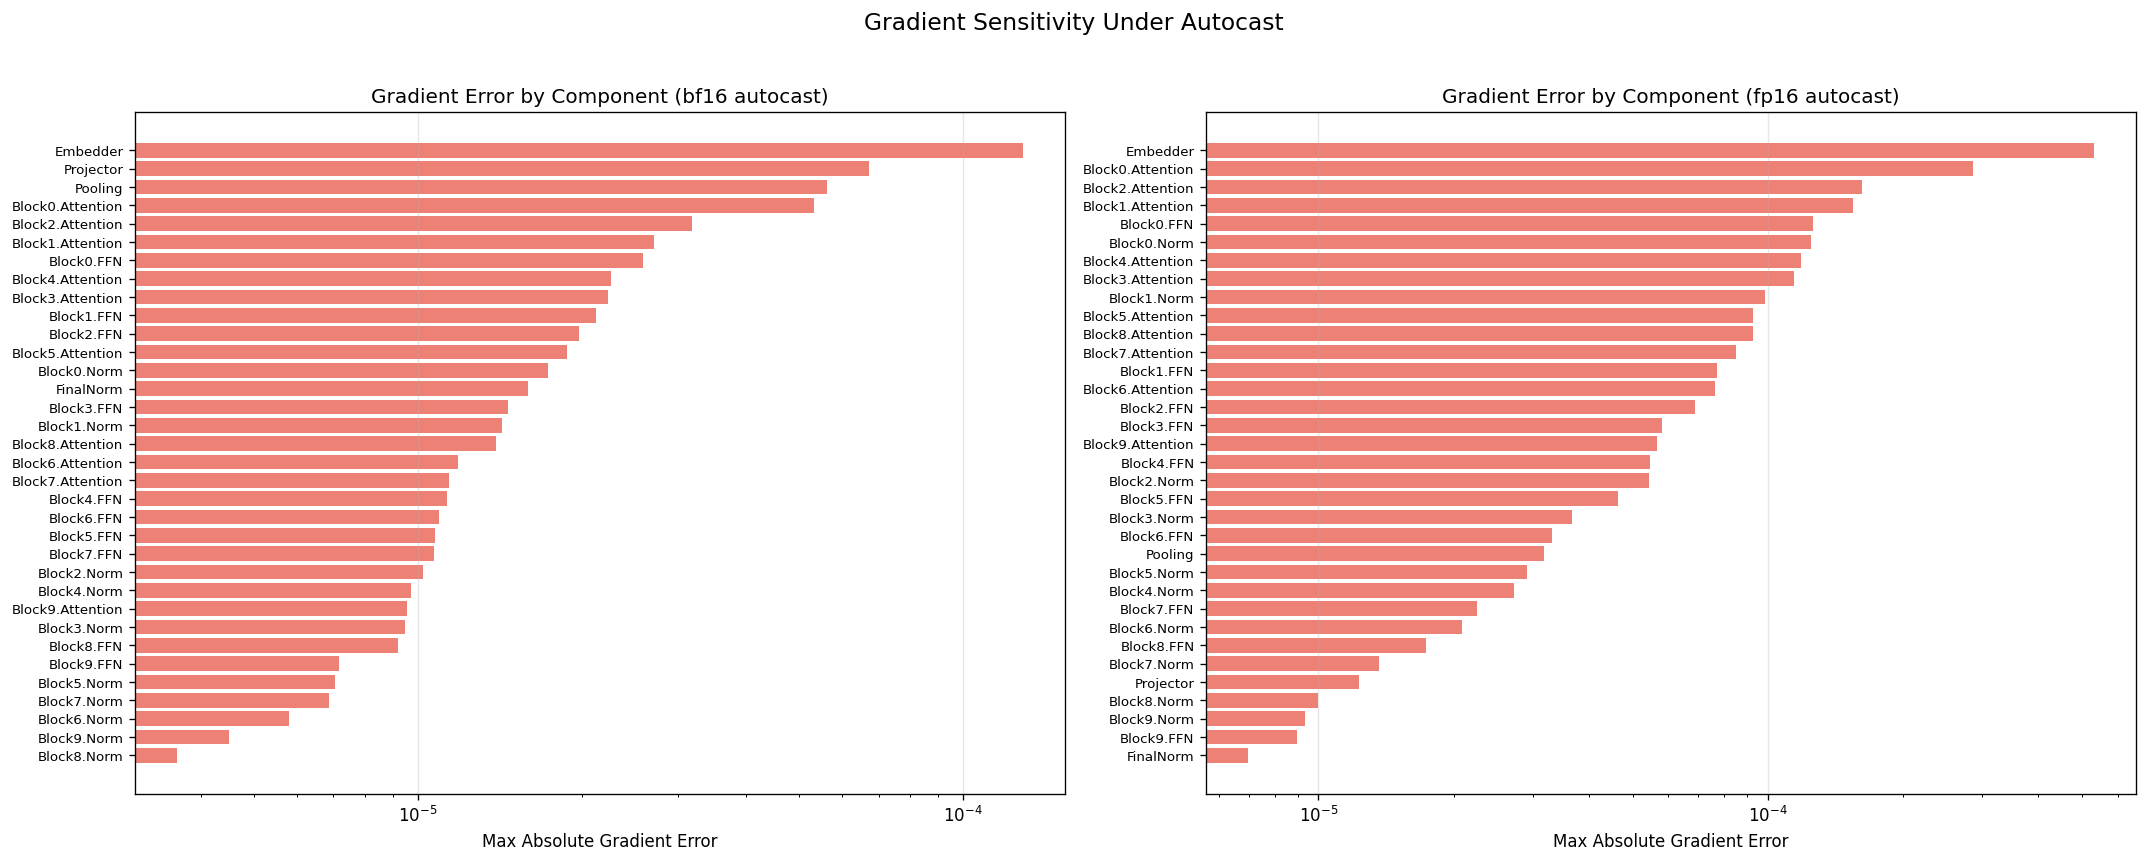

In [22]:
# Visualize gradient errors by category
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, ac_name, title_suffix in [
    (axes[0], "bf16_autocast", "bf16 autocast"),
    (axes[1], "fp16_autocast", "fp16 autocast"),
]:
    sub = grad_df[grad_df["autocast"] == ac_name].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f"{ac_name}: No data", transform=ax.transAxes, ha="center")
        continue

    # Group by category, show max_abs_err
    cat_stats = (
        sub.groupby("category")
        .agg(
            max_err=("max_abs_err", "max"),
            mean_err=("mean_abs_err", "mean"),
            min_cos=("cosine_sim", "min"),
            mean_cos=("cosine_sim", "mean"),
        )
        .sort_values("max_err", ascending=True)
    )

    y = np.arange(len(cat_stats))
    ax.barh(y, cat_stats["max_err"], color="#e74c3c", alpha=0.7, label="Max Abs Error")
    ax.set_yticks(y)
    ax.set_yticklabels(cat_stats.index, fontsize=8)
    ax.set_xlabel("Max Absolute Gradient Error")
    ax.set_title(f"Gradient Error by Component ({title_suffix})")
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3, axis="x")

fig.suptitle("Gradient Sensitivity Under Autocast", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("gradient_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()

## 10. RMSNorm Sensitivity Analysis

RMSNorm is used extensively (encoder final norm, pool norm, projector norms, per-block norms).
It involves a reduction operation (mean of squares) that can lose precision.

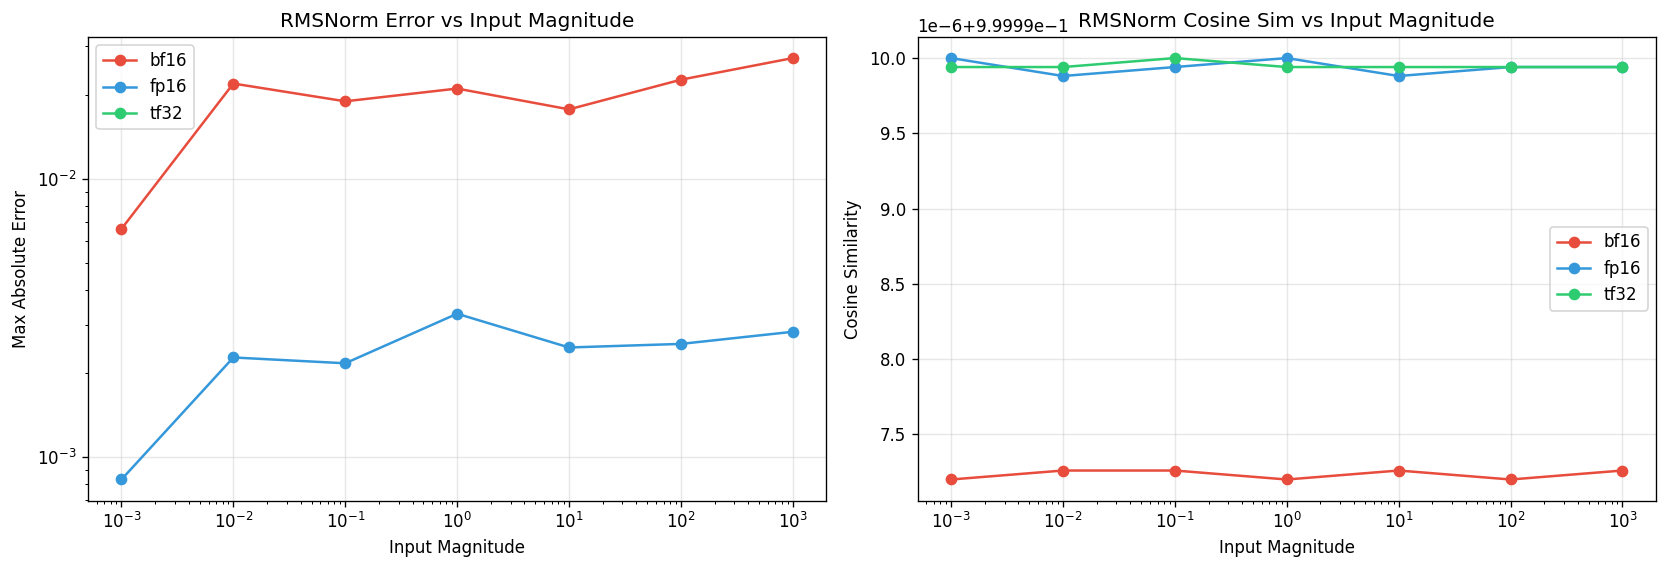

In [23]:
# Test RMSNorm with various input magnitudes and precisions
norm_layer = nn.RMSNorm(256, eps=1e-5).to(DEVICE)

magnitudes = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
norm_results = []

for mag in magnitudes:
    torch.manual_seed(42)
    x = torch.randn(16, 60, 256, device=DEVICE) * mag

    with torch.no_grad():
        ref = norm_layer(x.float()).float()

    for prec_name, (dtype, tf32) in PRECISIONS.items():
        if prec_name == "fp32":
            continue
        with torch.no_grad():
            if prec_name == "tf32":
                test = norm_layer(x.float()).float()
            else:
                test = norm_layer.to(dtype)(x.to(dtype)).float()
                norm_layer.to(torch.float32)

        m = compute_error_metrics(ref, test)
        norm_results.append(
            {
                "magnitude": mag,
                "precision": prec_name,
                **m,
            }
        )

norm_df = pd.DataFrame(norm_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for prec_name, color in [("bf16", "#e74c3c"), ("fp16", "#3498db"), ("tf32", "#2ecc71")]:
    sub = norm_df[norm_df["precision"] == prec_name]
    axes[0].loglog(
        sub["magnitude"], sub["max_abs_err"], "o-", label=prec_name, color=color
    )
    axes[1].semilogx(
        sub["magnitude"], sub["cosine_sim"], "o-", label=prec_name, color=color
    )

axes[0].set_xlabel("Input Magnitude")
axes[0].set_ylabel("Max Absolute Error")
axes[0].set_title("RMSNorm Error vs Input Magnitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Input Magnitude")
axes[1].set_ylabel("Cosine Similarity")
axes[1].set_title("RMSNorm Cosine Sim vs Input Magnitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rmsnorm_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()

## 11. Summary and Recommendations

In [24]:
# Final summary table
print("=" * 100)
print("NUMERICAL SENSITIVITY ANALYSIS SUMMARY")
print("=" * 100)

summary_df = pd.DataFrame(results)
print("\n--- Per-Component x Precision ---")
print(
    summary_df[
        [
            "component",
            "precision",
            "max_abs_err",
            "mean_abs_err",
            "max_rel_err",
            "cosine_sim",
            "has_nan",
            "has_inf",
        ]
    ].to_string(index=False)
)

print("\n--- torch.compile Results ---")
print(compile_df.to_string(index=False))

# Flag problematic components
print("\n" + "=" * 100)
print("RISK ASSESSMENT")
print("=" * 100)

nan_entries = summary_df[summary_df["has_nan"]]
if not nan_entries.empty:
    print("\n** NaN DETECTED in:")
    for _, row in nan_entries.iterrows():
        print(f"   - {row['component']} @ {row['precision']}")
else:
    print("\n  No NaN issues detected in any component/precision combination.")

inf_entries = summary_df[summary_df["has_inf"]]
if not inf_entries.empty:
    print("\n** Inf DETECTED in:")
    for _, row in inf_entries.iterrows():
        print(f"   - {row['component']} @ {row['precision']}")
else:
    print("  No Inf issues detected in any component/precision combination.")

high_err = summary_df[summary_df["max_rel_err"] > 0.1]
if not high_err.empty:
    print("\n** HIGH RELATIVE ERROR (>10%) in:")
    for _, row in high_err.iterrows():
        print(
            f"   - {row['component']} @ {row['precision']}: rel_err={row['max_rel_err']:.2e}"
        )

low_cos = summary_df[summary_df["cosine_sim"] < 0.99]
if not low_cos.empty:
    print("\n** LOW COSINE SIMILARITY (<0.99) in:")
    for _, row in low_cos.iterrows():
        print(
            f"   - {row['component']} @ {row['precision']}: cos_sim={row['cosine_sim']:.6f}"
        )

print("\n" + "=" * 100)
print("KEY OBSERVATIONS")
print("=" * 100)
print("""
1. FourierFeatures: The model already computes sin/cos in fp32 internally (see model code),
   which mitigates the high-frequency overflow risk. However, the cast back to input dtype
   still introduces quantization error proportional to the output magnitude.

2. bf16 vs fp16: bf16 has a much larger dynamic range (same as fp32) but only 7 bits of
   mantissa (vs 10 for fp16). This means bf16 won't overflow/underflow but has worse
   per-element precision. fp16 has better mantissa precision but risks overflow at high
   magnitudes.

3. tf32: Uses fp32 range with 10-bit mantissa for matmul operations. Errors are typically
   very small and limited to matrix multiplication kernels.

4. Error Accumulation: Errors grow through transformer layers. The 10-layer encoder shows
   significant error amplification, especially for bf16.

5. torch.compile: Different compile modes may produce slightly different results due to
   kernel selection. Combined with autocast, this can compound precision effects.

6. The training loop uses bf16 autocast + max-autotune compile, which is a reasonable
   trade-off between speed and numerical stability for this architecture.
""")

NUMERICAL SENSITIVITY ANALYSIS SUMMARY

--- Per-Component x Precision ---
              component precision  max_abs_err  mean_abs_err  max_rel_err  cosine_sim  has_nan  has_inf
        FourierFeatures      tf32 0.000000e+00  0.000000e+00 0.000000e+00    1.000000    False    False
        FourierFeatures      bf16 2.000000e+00  3.528256e-01 9.909278e+04    0.621641    False    False
        FourierFeatures      fp16 1.999997e+00  3.390891e-01 9.903023e+04    0.632803    False    False
    PeakFeatureEmbedder      tf32 6.777346e-04  1.041639e-04 5.739078e+04    1.000000    False    False
    PeakFeatureEmbedder      bf16 1.657403e+00  2.088307e-01 1.184139e+08    0.644791    False    False
    PeakFeatureEmbedder      fp16 1.194420e+00  1.161895e-01 2.980062e+07    0.865703    False    False
    TransformerBlock[0]      tf32 2.986431e-03  4.785967e-04 2.479821e+02    1.000000    False    False
    TransformerBlock[0]      bf16 3.401542e-02  5.516625e-03 2.924714e+03    0.999985    False

## 12. fp16 Mitigation Validation: fp32 Islands in Stem + PMA

This section validates an fp16 mitigation strategy:

- Keep global autocast in `fp16`
- Run `PeakFeatureEmbedder + TransformerBlock[0]` in `fp32`
- Run PMA pooling in `fp32`

We compare against baseline fp16 autocast using identical weights and inputs.


In [25]:
# Mitigation experiment: baseline fp16 vs fp16 + fp32 islands (stem + PMA)

mitigation_cfg = dict(MODEL_CFG)
mitigation_cfg["encoder_fp16_high_precision_stem"] = True
mitigation_cfg["pma_fp16_high_precision"] = True

baseline_model = PeakSetSIGReg(**MODEL_CFG).to(DEVICE).eval()
mitigated_model = PeakSetSIGReg(**mitigation_cfg).to(DEVICE).eval()
mitigated_model.load_state_dict(baseline_model.state_dict(), strict=True)

mit_batch = make_synthetic_batch(batch_size=B, device=DEVICE)
mit_aug = baseline_model.augment_batch(mit_batch)
mit_aug_fp32 = cast_tensors(mit_aug, torch.float32)
mit_proj = baseline_model.sample_bcs_projection(device=DEVICE, seed=2026).float()

with torch.no_grad():
    ref_metrics = baseline_model.forward_augmented(
        mit_aug_fp32, bcs_projection=mit_proj
    )

with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
    fp16_base_metrics = baseline_model.forward_augmented(
        mit_aug_fp32, bcs_projection=mit_proj
    )

with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
    fp16_mit_metrics = mitigated_model.forward_augmented(
        mit_aug_fp32, bcs_projection=mit_proj
    )

metric_keys = [
    "loss",
    "bcs_loss",
    "invariance_loss",
    "alignment",
    "uniformity",
    "representation_variance",
    "encoder_variance",
]

metric_rows = []
for key in metric_keys:
    ref_val = float(ref_metrics[key])
    base_val = float(fp16_base_metrics[key])
    mit_val = float(fp16_mit_metrics[key])
    base_abs_err = abs(base_val - ref_val)
    mit_abs_err = abs(mit_val - ref_val)
    improvement = base_abs_err / max(mit_abs_err, 1e-12)
    metric_rows.append(
        {
            "metric": key,
            "ref_fp32": ref_val,
            "fp16_baseline": base_val,
            "fp16_mitigated": mit_val,
            "abs_err_baseline": base_abs_err,
            "abs_err_mitigated": mit_abs_err,
            "error_reduction_factor": improvement,
        }
    )

mit_metrics_df = pd.DataFrame(metric_rows)
print("Mitigation metric comparison (higher error_reduction_factor is better):")
print(mit_metrics_df.to_string(index=False))

# Encoder and pool feature-level comparison
peak_mz = mit_batch["peak_mz"]
peak_intensity = mit_batch["peak_intensity"]
peak_valid_mask = mit_batch["peak_valid_mask"]

with torch.no_grad():
    ref_enc = baseline_model.encoder(
        peak_mz.float(), peak_intensity.float(), valid_mask=peak_valid_mask
    ).float()
    ref_pool = baseline_model.pool(ref_enc, peak_valid_mask).float()

with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
    base_enc = baseline_model.encoder(
        peak_mz.float(), peak_intensity.float(), valid_mask=peak_valid_mask
    ).float()
    base_pool = baseline_model.pool(base_enc, peak_valid_mask).float()

with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
    mit_enc = mitigated_model.encoder(
        peak_mz.float(), peak_intensity.float(), valid_mask=peak_valid_mask
    ).float()
    mit_pool = mitigated_model.pool(mit_enc, peak_valid_mask).float()

feature_rows = []
for name, ref, base, mit in [
    ("Encoder output", ref_enc, base_enc, mit_enc),
    ("PMA pooled", ref_pool, base_pool, mit_pool),
]:
    base_stats = compute_error_metrics(ref, base)
    mit_stats = compute_error_metrics(ref, mit)
    feature_rows.append(
        {
            "component": name,
            "baseline_mean_abs": base_stats["mean_abs_err"],
            "mitigated_mean_abs": mit_stats["mean_abs_err"],
            "baseline_max_abs": base_stats["max_abs_err"],
            "mitigated_max_abs": mit_stats["max_abs_err"],
            "baseline_cos": base_stats["cosine_sim"],
            "mitigated_cos": mit_stats["cosine_sim"],
            "mean_abs_reduction_factor": base_stats["mean_abs_err"]
            / max(mit_stats["mean_abs_err"], 1e-12),
        }
    )

feature_df = pd.DataFrame(feature_rows)
print("\nFeature-level comparison:")
print(feature_df.to_string(index=False))

Mitigation metric comparison (higher error_reduction_factor is better):
                 metric  ref_fp32  fp16_baseline  fp16_mitigated  abs_err_baseline  abs_err_mitigated  error_reduction_factor
                   loss  0.064008       0.064011        0.064005      2.510846e-06       3.479421e-06                0.721627
               bcs_loss  0.467536       0.467551        0.467536      1.528859e-05       7.748604e-07               19.730769
        invariance_loss  0.017255       0.017256        0.017251      9.797513e-07       3.557652e-06                0.275393
              alignment  0.931218       0.931227        0.931231      9.179115e-06       1.323223e-05                0.693694
             uniformity  0.846403       0.846391        0.846393      1.198053e-05       9.953976e-06                1.203593
representation_variance  0.018088       0.018097        0.018082      8.985400e-06       6.273389e-06                1.432304
       encoder_variance  0.149431       0.1494